Notice that in this version $K_F$ is allowed to be build up before entry. The rtesults show that most firms only build up capital the period before they enter so it is not that important anyway. However, the firm needs a positive $K_F$ for the cutoff to be well defined. 

V2: This version allows for firms to still export a part of their output when they have become a MNE (i.e entered HF). This allows for a partial transition

In [ ]:
from __future__ import annotations

from dataclasses import dataclass
from typing import Callable, Dict, List, Optional, Tuple

import numpy as np
from scipy.interpolate import RegularGridInterpolator


# ============================================================
# 1. REGIMES
# ============================================================

REGIMES_X_HF = ("X", "HF")


@dataclass(frozen=True)
class RegimeConfig:
    active_modes: Tuple[str, ...] = REGIMES_X_HF

    def __post_init__(self) -> None:
        allowed = {"X", "HF"}
        invalid = [m for m in self.active_modes if m not in allowed]
        if invalid:
            raise ValueError(f"Invalid regimes: {invalid}")
        if len(self.active_modes) == 0:
            raise ValueError("Need at least one active regime.")

    @property
    def mode_to_index(self) -> Dict[str, int]:
        return {m: i for i, m in enumerate(self.active_modes)}

    @property
    def index_to_mode(self) -> Dict[int, str]:
        return {i: m for i, m in enumerate(self.active_modes)}


# ============================================================
# 2. PARAMETERS
# ============================================================

@dataclass
class ModelParams:
    # Dynamic
    beta: float = 0.98
    delta: float = 0.10   # keep one common depreciation rate for now

    # Adjustment costs
    phi_H: float = 1.5
    phi_F: float = 1.8

    # Terminal liquidation values
    xi_H: float = 0.40
    xi_F: float = 0.40

    # Marginal investment costs
    q_H: float = 1.0
    q_F: float = 1.0

    # CES / reduced-form parameters
    sigma: float = 5.0
    alpha: float = 0.30

    # Demand / cost shifters
    A_H: float = 1.0
    A_F: float = 1.0
    Lambda_H: float = 1.0
    Lambda_F: float = 1.0
    w_H: float = 1.0
    w_F: float = 1.0
    tau_X: float = 1.15

    # Regime-level operating fixed costs
    f_X_op: float = 0.045
    f_HF_op: float = 0.065

    # Regime-level sunk costs
    # In the current X/HF-only code, only f_HF_E matters for X -> HF switching,
    # but keep f_X_E for consistency with the written model.
    f_X_E: float = 0.0
    f_HF_E: float = 0.15

    eps: float = 1e-10

    @property
    def a(self) -> float:
        return (self.sigma - 1.0) / self.sigma

    @property
    def gamma(self) -> float:
        return 1.0 - self.alpha

    @property
    def mu(self) -> float:
        val = 1.0 - self.a * self.gamma
        if val <= 0:
            raise ValueError("Need mu = 1 - a * gamma > 0.")
        return val

    @property
    def rho(self) -> float:
        return self.a / self.mu

    @property
    def kappa(self) -> float:
        return self.alpha * self.rho


# ============================================================
# 3. PRODUCTIVITY PROCESSES
# ============================================================

def make_constant_productivity_transition(n_s: int) -> np.ndarray:
    """Deterministic productivity process: s_{t+1} = s_t."""
    return np.eye(n_s)


def fixed_s_process(s_value: float) -> Tuple[np.ndarray, np.ndarray]:
    """One-point productivity grid with constant s over time."""
    if s_value <= 0.0:
        raise ValueError("Need s_value > 0.")
    s_grid = np.array([float(s_value)])
    P = make_constant_productivity_transition(1)
    return s_grid, P


def rouwenhorst(
    n: int,
    rho: float,
    sigma_eps: float,
    mu: float = 0.0,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    if n < 2:
        raise ValueError("n must be at least 2.")
    if abs(rho) >= 1.0:
        raise ValueError("Need |rho| < 1 for a stationary AR(1).")

    prob = (1.0 + rho) / 2.0
    P = np.array([[1.0]])

    for m in range(2, n + 1):
        P_new = np.zeros((m, m))
        P_new[:-1, :-1] += prob * P
        P_new[:-1, 1:] += (1.0 - prob) * P
        P_new[1:, :-1] += (1.0 - prob) * P
        P_new[1:, 1:] += prob * P
        P_new[1:-1, :] /= 2.0
        P = P_new

    sigma_z = sigma_eps / np.sqrt(1.0 - rho**2)
    psi = sigma_z * np.sqrt(n - 1)
    z_grid = np.linspace(-psi, psi, n) + mu
    s_grid = np.exp(z_grid)
    return z_grid, s_grid, P


# ============================================================
# 4. TECHNOLOGY, PROFITS, COSTS
# ============================================================

# OLD
# def investment_cost(i: float, phi: float, q: float) -> float:
    return q * i + 0.5 * phi * i**2

# NEW
def investment_cost(i: float, K: float, phi: float, q: float, eps: float = 1e-10) -> float:
    K_eff = max(K, eps)
    return q * i + 0.5 * phi * (i**2) / K_eff

def next_capital(K: float, i: float, delta: float) -> float:
    return (1.0 - delta) * K + i


def terminal_value(KH: float, KF: float, p: ModelParams) -> float:
    return p.xi_H * KH + p.xi_F * KF


def switching_cost(prev_mode: str, new_mode: str, p: ModelParams) -> float:
    """
    Three-period note:
        Cadd(X | X)   = 0
        Cadd(HF | HF) = 0
        Cadd(HF | X)  = f_HF_E
        Cadd(X | HF)  = 0   (if downgrading allowed)
    """
    if prev_mode == new_mode:
        return 0.0
    if prev_mode == "X" and new_mode == "HF":
        return p.f_HF_E
    if prev_mode == "HF" and new_mode == "X":
        return 0.0
    return 0.0


def _safe_power(x: float, power: float, eps: float) -> float:
    return max(x, eps) ** power


def Gamma_X(p: ModelParams) -> float:
    return (p.Lambda_F / (p.tau_X * p.Lambda_H)) ** p.sigma


def Xi_X(p: ModelParams) -> float:
    GX = Gamma_X(p)
    return p.Lambda_H + p.Lambda_F * (GX ** p.a)


def omega_H(p: ModelParams) -> float:
    Rbar_H = p.Lambda_H * ((p.a * p.gamma * p.Lambda_H) / p.w_H) ** (p.a * p.gamma / p.mu)
    return p.mu * Rbar_H * (p.A_H ** p.rho)


def omega_F(p: ModelParams) -> float:
    Rbar_F = p.Lambda_F * ((p.a * p.gamma * p.Lambda_F) / p.w_F) ** (p.a * p.gamma / p.mu)
    return p.mu * Rbar_F * (p.A_F ** p.rho)


def omega_X(p: ModelParams) -> float:
    GX = Gamma_X(p)
    XX = Xi_X(p)
    w_X_eff = p.w_H * (1.0 + p.tau_X * GX) ** (1.0 / p.gamma)
    Rbar_X = XX * ((p.a * p.gamma * XX) / w_X_eff) ** (p.a * p.gamma / p.mu)
    return p.mu * Rbar_X * (p.A_H ** p.rho)


def omega_HF0(p: ModelParams) -> float:
    """
    Mixed HF block with coexistence of exports and affiliate sales.
    """
    GX = Gamma_X(p)
    XX = Xi_X(p)
    denom = p.w_H * (1.0 + p.tau_X * GX) ** (1.0 / p.gamma)
    return p.mu * XX * ((p.a * p.gamma * XX) / denom) ** (p.a * p.gamma / p.mu)


def eta_HF(p: ModelParams) -> float:
    """
    In the written model: eta = alpha(1-phi)/(1-gamma).
    In this code there is no separate production-friction phi in the production block,
    so with gamma = 1 - alpha this simplifies to eta = 1.
    Kept in function form for clarity and future extensions.
    """
    return p.alpha / (1.0 - p.gamma)


def Delta_F_HF(p: ModelParams) -> float:
    return (
        p.tau_X ** (1.0 / (1.0 - p.gamma))
        * (p.w_H / p.w_F) ** (p.gamma / (1.0 - p.gamma))
    )


def profit_D(KH: float, s: float, p: ModelParams) -> float:
    # not used in the X/HF-only model, but harmless to keep
    return omega_H(p) * _safe_power(KH, p.kappa, p.eps) * (s ** p.rho)


def profit_X(KH: float, s: float, p: ModelParams) -> float:
    return omega_X(p) * _safe_power(KH, p.kappa, p.eps) * (s ** p.rho) - p.f_X_op


def profit_HF(KH: float, KF: float, s: float, p: ModelParams) -> float:
    eta = eta_HF(p)
    DeltaF = Delta_F_HF(p)

    composite = (
        _safe_power(KH, eta, p.eps)
        + DeltaF * _safe_power(KF, eta, p.eps)
    )

    return (
        omega_HF0(p)
        * (s ** p.rho)
        * _safe_power(composite, p.rho * (1.0 - p.gamma), p.eps)
        - p.f_HF_op
    )


def flow_profit(mode: str, KH: float, KF: float, s: float, p: ModelParams) -> float:
    if mode == "X":
        return profit_X(KH, s, p)
    if mode == "HF":
        return profit_HF(KH, KF, s, p)
    raise ValueError(f"Unknown mode: {mode}")

# ============================================================
# 5. INTERPOLATION / EXPECTATIONS
# ============================================================

def _clip(x: float, grid: np.ndarray) -> float:
    return float(np.clip(x, grid[0], grid[-1]))


def nearest_index(grid: np.ndarray, x: float) -> int:
    return int(np.argmin(np.abs(grid - x)))


def local_index_window(center: int, n: int, radius: int) -> np.ndarray:
    lo = max(center - radius, 0)
    hi = min(center + radius, n - 1)
    return np.arange(lo, hi + 1)


def build_value_interpolators(
    KH_grid: np.ndarray,
    KF_grid: np.ndarray,
    s_grid: np.ndarray,
    V: np.ndarray,
    cfg: RegimeConfig,
) -> Dict[Tuple[str, int], RegularGridInterpolator]:
    interps: Dict[Tuple[str, int], RegularGridInterpolator] = {}

    for pm, prev_mode in enumerate(cfg.active_modes):
        for s_idx in range(len(s_grid)):
            interps[(prev_mode, s_idx)] = RegularGridInterpolator(
                (KH_grid, KF_grid),
                V[pm, :, :, s_idx],
                bounds_error=False,
                fill_value=None,
            )
    return interps


def make_value_callable(
    KH_grid: np.ndarray,
    KF_grid: np.ndarray,
    interps: Dict[Tuple[str, int], RegularGridInterpolator],
) -> Callable[[str, float, float, int], float]:
    def value_obj(prev_mode: str, KH: float, KF: float, s_idx: int) -> float:
        KHc = _clip(KH, KH_grid)
        KFc = _clip(KF, KF_grid)
        return float(interps[(prev_mode, s_idx)](np.array([[KHc, KFc]]))[0])

    return value_obj


def build_expected_grid_from_markov(
    V_next: np.ndarray,
    P: np.ndarray,
    beta: float,
) -> np.ndarray:
    """
    V_next shape:
        (n_prev_mode, n_KH, n_KF, n_s_next)

    Returns:
        EV shape = (n_prev_mode, n_KH, n_KF, n_s_current)
        with EV[..., s_cur] = beta * E[V_next | s_cur]
    """
    n_prev, n_KH, n_KF, _ = V_next.shape
    n_s_cur = P.shape[0]

    EV = np.empty((n_prev, n_KH, n_KF, n_s_cur))
    for pm in range(n_prev):
        for s_cur in range(n_s_cur):
            EV[pm, :, :, s_cur] = beta * np.tensordot(
                V_next[pm, :, :, :],
                P[s_cur, :],
                axes=([2], [0]),
            )
    return EV


def build_expected_interpolators(
    KH_grid: np.ndarray,
    KF_grid: np.ndarray,
    EV: np.ndarray,
    cfg: RegimeConfig,
) -> Dict[Tuple[str, int], RegularGridInterpolator]:
    interps: Dict[Tuple[str, int], RegularGridInterpolator] = {}

    for pm, prev_mode in enumerate(cfg.active_modes):
        for s_idx in range(EV.shape[3]):
            interps[(prev_mode, s_idx)] = RegularGridInterpolator(
                (KH_grid, KF_grid),
                EV[pm, :, :, s_idx],
                bounds_error=False,
                fill_value=None,
            )
    return interps


def make_expected_value_callable(
    KH_grid: np.ndarray,
    KF_grid: np.ndarray,
    interps: Dict[Tuple[str, int], RegularGridInterpolator],
) -> Callable[[str, float, float, int], float]:
    def EV_obj(prev_mode: str, KH: float, KF: float, s_idx: int) -> float:
        KHc = _clip(KH, KH_grid)
        KFc = _clip(KF, KF_grid)
        return float(interps[(prev_mode, s_idx)](np.array([[KHc, KFc]]))[0])

    return EV_obj


# ============================================================
# 6. FAST TERMINAL-PERIOD SOLVER
# ============================================================
from dataclasses import replace

# OLD
def terminal_investment_kkt(p: ModelParams) -> Tuple[float, float]:
    """
    Last decision period:
        q_H + phi_H * i_H = beta * xi_H
        q_F + phi_F * i_F = beta * xi_F
    with non-negativity constraints.

    Also handles the zero-friction case phi = 0.
    """
    # Home
    if p.phi_H > 0:
        iH = max((p.beta * p.xi_H - p.q_H) / p.phi_H, 0.0)
    else:
        if p.q_H >= p.beta * p.xi_H:
            iH = 0.0
        else:
            raise ValueError(
                "Terminal problem is unbounded for H when phi_H=0 and q_H < beta*xi_H."
            )

    # Foreign
    if p.phi_F > 0:
        iF = max((p.beta * p.xi_F - p.q_F) / p.phi_F, 0.0)
    else:
        if p.q_F >= p.beta * p.xi_F:
            iF = 0.0
        else:
            raise ValueError(
                "Terminal problem is unbounded for F when phi_F=0 and q_F < beta*xi_F."
            )

    return float(iH), float(iF)


def solve_terminal_branch(
    mode: str,
    prev_mode: str,
    KH: float,
    KF: float,
    s: float,
    p: ModelParams,
) -> Dict[str, float]:
    iH, iF = terminal_investment_kkt(p)

    KH_next = next_capital(KH, iH, p.delta)
    KF_next = next_capital(KF, iF, p.delta)

    pi = flow_profit(mode, KH, KF, s, p)
    switch = switching_cost(prev_mode, mode, p)
    adjust = investment_cost(iH, p.phi_H, p.q_H) + investment_cost(iF, p.phi_F, p.q_F)
    cont = p.beta * terminal_value(KH_next, KF_next, p)

    return {
        "mode": mode,
        "value": pi - switch - adjust + cont,
        "profit": pi,
        "switch_cost": switch,
        "iH": iH,
        "iF": iF,
        "KH_next": KH_next,
        "KF_next": KF_next,
        "continuation": cont,
    }


def solve_terminal_period_grid(
    KH_grid: np.ndarray,
    KF_grid: np.ndarray,
    s_grid: np.ndarray,
    p: ModelParams,
    cfg: RegimeConfig,
) -> Dict[str, object]:
    n_prev = len(cfg.active_modes)
    n_KH = len(KH_grid)
    n_KF = len(KF_grid)
    n_s = len(s_grid)

    V = np.empty((n_prev, n_KH, n_KF, n_s))
    policy_mode = np.empty((n_prev, n_KH, n_KF, n_s), dtype=int)
    iH_star = np.empty((n_prev, n_KH, n_KF, n_s))
    iF_star = np.empty((n_prev, n_KH, n_KF, n_s))
    KH_next_star = np.empty((n_prev, n_KH, n_KF, n_s))
    KF_next_star = np.empty((n_prev, n_KH, n_KF, n_s))

    for pm, prev_mode in enumerate(cfg.active_modes):
        for i, KH in enumerate(KH_grid):
            for j, KF in enumerate(KF_grid):
                for k, s in enumerate(s_grid):
                    branches = {
                        mode: solve_terminal_branch(
                            mode=mode,
                            prev_mode=prev_mode,
                            KH=KH,
                            KF=KF,
                            s=s,
                            p=p,
                        )
                        for mode in cfg.active_modes
                    }
                    best_mode = max(cfg.active_modes, key=lambda m: branches[m]["value"])
                    best = branches[best_mode]

                    V[pm, i, j, k] = best["value"]
                    policy_mode[pm, i, j, k] = cfg.mode_to_index[best_mode]
                    iH_star[pm, i, j, k] = best["iH"]
                    iF_star[pm, i, j, k] = best["iF"]
                    KH_next_star[pm, i, j, k] = best["KH_next"]
                    KF_next_star[pm, i, j, k] = best["KF_next"]

    interps = build_value_interpolators(KH_grid, KF_grid, s_grid, V, cfg)
    value_obj = make_value_callable(KH_grid, KF_grid, interps)

    return {
        "V": V,
        "policy_mode": policy_mode,
        "iH_star": iH_star,
        "iF_star": iF_star,
        "KH_next_star": KH_next_star,
        "KF_next_star": KF_next_star,
        "interpolators": interps,
        "value_callable": value_obj,
    }


# ============================================================
# 7. FAST PRE-TERMINAL SOLVER
# ============================================================

def solve_branch_local_search(
    mode: str,
    prev_mode: str,
    KH: float,
    KF: float,
    s_idx: int,
    s_grid: np.ndarray,
    EV_obj: Callable[[str, float, float, int], float],
    p: ModelParams,
    KH_grid: np.ndarray,
    KF_grid: np.ndarray,
    radius: int = 7,
    max_expansions: int = 5,
) -> Dict[str, float]:
    """
    Fast local search over next-period capital grid points.

    The search starts around depreciated current capital and expands only if
    the optimum hits the edge of the local window.
    """
    s = float(s_grid[s_idx])

    center_H = nearest_index(KH_grid, (1.0 - p.delta) * KH)
    center_F = nearest_index(KF_grid, (1.0 - p.delta) * KF)

    n_H = len(KH_grid)
    n_F = len(KF_grid)
    visited = set()
    best: Optional[Dict[str, float]] = None

    for _ in range(max_expansions):
        key = (center_H, center_F)
        if key in visited:
            break
        visited.add(key)

        idx_H = local_index_window(center_H, n_H, radius)
        idx_F = local_index_window(center_F, n_F, radius)

        best_val = -np.inf
        best_idx: Optional[Tuple[int, int]] = None
        best_local: Optional[Dict[str, float]] = None

        for iH_idx in idx_H:
            KH_next = float(KH_grid[iH_idx])
            iH = KH_next - (1.0 - p.delta) * KH
            if iH < -1e-12:
                continue

            for iF_idx in idx_F:
                KF_next = float(KF_grid[iF_idx])
                iF = KF_next - (1.0 - p.delta) * KF
                if iF < -1e-12:
                    continue

                pi = flow_profit(mode, KH, KF, s, p)
                switch = switching_cost(prev_mode, mode, p)
                adjust = investment_cost(iH, p.phi_H, p.q_H) + investment_cost(iF, p.phi_F, p.q_F)
                EV = EV_obj(mode, KH_next, KF_next, s_idx)
                val = pi - switch - adjust + EV

                if val > best_val:
                    best_val = val
                    best_idx = (iH_idx, iF_idx)
                    best_local = {
                        "mode": mode,
                        "value": val,
                        "profit": pi,
                        "switch_cost": switch,
                        "iH": float(iH),
                        "iF": float(iF),
                        "KH_next": KH_next,
                        "KF_next": KF_next,
                        "EV": EV,
                    }

        if best_idx is None or best_local is None:
            raise RuntimeError("Local search failed to find a feasible candidate.")

        best = best_local
        iH_idx, iF_idx = best_idx

        hit_edge_H = ((iH_idx == idx_H[0]) and (iH_idx > 0)) or ((iH_idx == idx_H[-1]) and (iH_idx < n_H - 1))
        hit_edge_F = ((iF_idx == idx_F[0]) and (iF_idx > 0)) or ((iF_idx == idx_F[-1]) and (iF_idx < n_F - 1))

        if hit_edge_H or hit_edge_F:
            center_H, center_F = iH_idx, iF_idx
            continue

        break

    if best is None:
        raise RuntimeError("Local search terminated without a solution.")

    return best


def solve_nonterminal_period_grid(
    KH_grid: np.ndarray,
    KF_grid: np.ndarray,
    s_grid: np.ndarray,
    P: np.ndarray,
    next_period_sol: Dict[str, object],
    p: ModelParams,
    cfg: RegimeConfig,
    radius: int = 7,
    max_expansions: int = 5,
) -> Dict[str, object]:
    EV_grid = build_expected_grid_from_markov(
        V_next=next_period_sol["V"],
        P=P,
        beta=p.beta,
    )
    EV_interps = build_expected_interpolators(KH_grid, KF_grid, EV_grid, cfg)
    EV_obj = make_expected_value_callable(KH_grid, KF_grid, EV_interps)

    n_prev = len(cfg.active_modes)
    n_KH = len(KH_grid)
    n_KF = len(KF_grid)
    n_s = len(s_grid)

    V = np.empty((n_prev, n_KH, n_KF, n_s))
    policy_mode = np.empty((n_prev, n_KH, n_KF, n_s), dtype=int)
    iH_star = np.empty((n_prev, n_KH, n_KF, n_s))
    iF_star = np.empty((n_prev, n_KH, n_KF, n_s))
    KH_next_star = np.empty((n_prev, n_KH, n_KF, n_s))
    KF_next_star = np.empty((n_prev, n_KH, n_KF, n_s))

    for pm, prev_mode in enumerate(cfg.active_modes):
        for i, KH in enumerate(KH_grid):
            for j, KF in enumerate(KF_grid):
                for s_idx in range(n_s):
                    branches = {
                        mode: solve_branch_local_search(
                            mode=mode,
                            prev_mode=prev_mode,
                            KH=KH,
                            KF=KF,
                            s_idx=s_idx,
                            s_grid=s_grid,
                            EV_obj=EV_obj,
                            p=p,
                            KH_grid=KH_grid,
                            KF_grid=KF_grid,
                            radius=radius,
                            max_expansions=max_expansions,
                        )
                        for mode in cfg.active_modes
                    }
                    best_mode = max(cfg.active_modes, key=lambda m: branches[m]["value"])
                    best = branches[best_mode]

                    V[pm, i, j, s_idx] = best["value"]
                    policy_mode[pm, i, j, s_idx] = cfg.mode_to_index[best_mode]
                    iH_star[pm, i, j, s_idx] = best["iH"]
                    iF_star[pm, i, j, s_idx] = best["iF"]
                    KH_next_star[pm, i, j, s_idx] = best["KH_next"]
                    KF_next_star[pm, i, j, s_idx] = best["KF_next"]

    interps = build_value_interpolators(KH_grid, KF_grid, s_grid, V, cfg)
    value_obj = make_value_callable(KH_grid, KF_grid, interps)

    return {
        "V": V,
        "policy_mode": policy_mode,
        "iH_star": iH_star,
        "iF_star": iF_star,
        "KH_next_star": KH_next_star,
        "KF_next_star": KF_next_star,
        "interpolators": interps,
        "value_callable": value_obj,
        "expected_grid": EV_grid,
        "expected_interpolators": EV_interps,
        "expected_callable": EV_obj,
    }


# ============================================================
# 8. GENERIC FINITE-HORIZON SOLVER
# ============================================================

def solve_finite_horizon_fast(
    KH_grid: np.ndarray,
    KF_grid: np.ndarray,
    s_grid: np.ndarray,
    P: np.ndarray,
    n_periods: int,
    p: ModelParams,
    cfg: RegimeConfig,
    radius: int = 7,
    max_expansions: int = 5,
) -> Dict[str, object]:
    """
    Solve a finite-horizon model with n_periods decision periods.

    Timing:
        t = 0, ..., n_periods - 1     : regime and investment choice
        t = n_periods                 : liquidation value only

    The last decision period is solved with the closed-form KKT.
    All earlier periods use the fast expectation-based local search.
    """
    if n_periods < 1:
        raise ValueError("Need n_periods >= 1.")

    period_solutions: List[Optional[Dict[str, object]]] = [None] * n_periods

    period_solutions[-1] = solve_terminal_period_grid(
        KH_grid=KH_grid,
        KF_grid=KF_grid,
        s_grid=s_grid,
        p=p,
        cfg=cfg,
    )

    for t in range(n_periods - 2, -1, -1):
        period_solutions[t] = solve_nonterminal_period_grid(
            KH_grid=KH_grid,
            KF_grid=KF_grid,
            s_grid=s_grid,
            P=P,
            next_period_sol=period_solutions[t + 1],
            p=p,
            cfg=cfg,
            radius=radius,
            max_expansions=max_expansions,
        )

    return {
        "KH_grid": KH_grid,
        "KF_grid": KF_grid,
        "s_grid": s_grid,
        "P": P,
        "n_periods": n_periods,
        "p": p,
        "cfg": cfg,
        "period_solutions": period_solutions,
        "solution_t0": period_solutions[0],
    }


# ============================================================
# 9. FIXED-s SOLVER
# ============================================================

def solve_fixed_s_finite_horizon(
    s_value: float,
    KH_grid: np.ndarray,
    KF_grid: np.ndarray,
    n_periods: int,
    p: ModelParams,
    cfg: RegimeConfig,
    radius: int = 7,
    max_expansions: int = 5,
) -> Dict[str, object]:
    s_grid, P = fixed_s_process(s_value)

    bundle = solve_finite_horizon_fast(
        KH_grid=KH_grid,
        KF_grid=KF_grid,
        s_grid=s_grid,
        P=P,
        n_periods=n_periods,
        p=p,
        cfg=cfg,
        radius=radius,
        max_expansions=max_expansions,
    )
    bundle["solver_type"] = "fixed_s"
    bundle["s_value"] = float(s_value)
    return bundle


# ============================================================
# 10. STOCHASTIC-s SOLVER
# ============================================================

def solve_stochastic_s_finite_horizon(
    KH_grid: np.ndarray,
    KF_grid: np.ndarray,
    s_grid: np.ndarray,
    P: np.ndarray,
    n_periods: int,
    p: ModelParams,
    cfg: RegimeConfig,
    radius: int = 7,
    max_expansions: int = 5,
) -> Dict[str, object]:
    bundle = solve_finite_horizon_fast(
        KH_grid=KH_grid,
        KF_grid=KF_grid,
        s_grid=s_grid,
        P=P,
        n_periods=n_periods,
        p=p,
        cfg=cfg,
        radius=radius,
        max_expansions=max_expansions,
    )
    bundle["solver_type"] = "stochastic_s"
    return bundle


def solve_rouwenhorst_finite_horizon(
    KH_grid: np.ndarray,
    KF_grid: np.ndarray,
    n_periods: int,
    p: ModelParams,
    cfg: RegimeConfig,
    n_s: int = 11,
    rho: float = 0.90,
    sigma_eps: float = 0.12,
    mu: float = 0.0,
    radius: int = 7,
    max_expansions: int = 5,
) -> Dict[str, object]:
    z_grid, s_grid, P = rouwenhorst(n=n_s, rho=rho, sigma_eps=sigma_eps, mu=mu)

    bundle = solve_stochastic_s_finite_horizon(
        KH_grid=KH_grid,
        KF_grid=KF_grid,
        s_grid=s_grid,
        P=P,
        n_periods=n_periods,
        p=p,
        cfg=cfg,
        radius=radius,
        max_expansions=max_expansions,
    )
    bundle["z_grid"] = z_grid
    return bundle


# ============================================================
# 11. POLICY SIMULATION
# ============================================================

def simulate_one_path(
    model_bundle: Dict[str, object],
    KH0: float,
    KF0: float,
    s0_idx: int,
    initial_prev_mode: str = "X",
    stochastic: bool = True,
    seed: Optional[int] = None,
) -> Dict[str, object]:
    KH_grid = model_bundle["KH_grid"]
    KF_grid = model_bundle["KF_grid"]
    s_grid = model_bundle["s_grid"]
    P = model_bundle["P"]
    cfg = model_bundle["cfg"]
    n_periods = model_bundle["n_periods"]
    period_solutions = model_bundle["period_solutions"]

    rng = np.random.default_rng(seed)

    KH_path = [float(KH0)]
    KF_path = [float(KF0)]
    s_idx_path = [int(s0_idx)]
    s_path = [float(s_grid[s0_idx])]
    mode_path: List[str] = []
    iH_path: List[float] = []
    iF_path: List[float] = []

    prev_mode = initial_prev_mode

    for t in range(n_periods):
        sol_t = period_solutions[t]

        i = nearest_index(KH_grid, KH_path[-1])
        j = nearest_index(KF_grid, KF_path[-1])
        k = s_idx_path[-1]
        pm = cfg.mode_to_index[prev_mode]

        mode = cfg.index_to_mode[int(sol_t["policy_mode"][pm, i, j, k])]
        iH = float(sol_t["iH_star"][pm, i, j, k])
        iF = float(sol_t["iF_star"][pm, i, j, k])
        KH_next = float(sol_t["KH_next_star"][pm, i, j, k])
        KF_next = float(sol_t["KF_next_star"][pm, i, j, k])

        mode_path.append(mode)
        iH_path.append(iH)
        iF_path.append(iF)
        KH_path.append(KH_next)
        KF_path.append(KF_next)

        if t < n_periods - 1:
            if stochastic:
                k_next = int(rng.choice(np.arange(len(s_grid)), p=P[k, :]))
            else:
                k_next = k
            s_idx_path.append(k_next)
            s_path.append(float(s_grid[k_next]))

        prev_mode = mode

    return {
        "KH_path": KH_path,
        "KF_path": KF_path,
        "s_idx_path": s_idx_path,
        "s_path": s_path,
        "mode_path": mode_path,
        "iH_path": iH_path,
        "iF_path": iF_path,
    }


def simulate_many_paths(
    model_bundle: Dict[str, object],
    KH0: float,
    KF0: float,
    s0_idx: int,
    n_firms: int = 100,
    initial_prev_mode: str = "X",
    stochastic: bool = True,
    seed: int = 123,
) -> List[Dict[str, object]]:
    rng = np.random.default_rng(seed)
    seeds = rng.integers(0, 2**32 - 1, size=n_firms)

    return [
        simulate_one_path(
            model_bundle=model_bundle,
            KH0=KH0,
            KF0=KF0,
            s0_idx=s0_idx,
            initial_prev_mode=initial_prev_mode,
            stochastic=stochastic,
            seed=int(seeds[i]),
        )
        for i in range(n_firms)
    ]


# ============================================================
# 12. SMALL PRINTER
# ============================================================

def print_path_summary(path: Dict[str, object], label: str = "path") -> None:
    print(f"\\n=== {label} ===")
    print("modes:   ", path["mode_path"])
    print("iH path: ", [round(x, 4) for x in path["iH_path"]])
    print("iF path: ", [round(x, 4) for x in path["iF_path"]])
    print("KH path: ", [round(x, 4) for x in path["KH_path"]])
    print("KF path: ", [round(x, 4) for x in path["KF_path"]])
    print("s path:  ", [round(x, 4) for x in path["s_path"]])

In [2]:
cfg = RegimeConfig(active_modes=("X", "HF"))
p = ModelParams()

KH_grid = np.linspace(0.10, 4.0, 40)
KF_grid = np.linspace(0.00, 2.0, 20)

# Fixed-s version
model_fixed = solve_fixed_s_finite_horizon(
    s_value=1.0,
    KH_grid=KH_grid,
    KF_grid=KF_grid,
    n_periods=13,
    p=p,
    cfg=cfg,
)

In [3]:
# Stochastic version
z_grid, s_grid, P = rouwenhorst(n=15, rho=0.90, sigma_eps=0.12)
model_stoch = solve_stochastic_s_finite_horizon(
    KH_grid=KH_grid,
    KF_grid=KF_grid,
    s_grid=s_grid,
    P=P,
    n_periods=13,
    p=p,
    cfg=cfg,
)

from dataclasses import replace


1. For 11 prod states

    a.  $50 \times 50$ states takes 32 minutes to solve 

    b. $40 \times 20$ takes 6 minutes

2. For 19 prod states. 

    b. $40 \times 20$ takes 12 minutes


In [7]:
# No-friction version
p_no_fric = replace(p, phi_H=0.0, phi_F=0.0)

model_stoch_no_fric = solve_stochastic_s_finite_horizon(
    KH_grid=KH_grid,
    KF_grid=KF_grid,
    s_grid=s_grid,
    P=P,
    n_periods=13,
    p=p_no_fric,
    cfg=cfg,
)

# Analysis 

### Step 1: Build inital exporter set

In [9]:
import numpy as np
import pandas as pd

def collect_initial_exporter_states(
    model_bundle: Dict[str, object],
    KF0_target: float = 0.0,
    initial_prev_mode: str = "X",
    kh_step: int = 1,
    s_idx_subset: Optional[list[int]] = None,
    require_static_export_premium: bool = True,
    export_premium_tol: float = 0.0,
) -> pd.DataFrame:
    """
    Collect initial states (s0, KH0, KF0) such that:
      - previous mode is X
      - KF0 is fixed near KF0_target
      - the optimal policy at t=0 is X in the reduced X/HF model
      - optionally: exporting weakly dominates domestic production on current flow profits

    Returns a DataFrame with one row per initial exporter state.
    """
    KH_grid = model_bundle["KH_grid"]
    KF_grid = model_bundle["KF_grid"]
    s_grid = model_bundle["s_grid"]
    p = model_bundle["p"]
    cfg = model_bundle["cfg"]
    sol_t0 = model_bundle["solution_t0"]

    pm = cfg.mode_to_index[initial_prev_mode]
    x_idx = cfg.mode_to_index["X"]
    j0 = nearest_index(KF_grid, KF0_target)

    if s_idx_subset is None:
        s_idx_subset = list(range(len(s_grid)))

    rows = []
    for s_idx in s_idx_subset:
        for i in range(0, len(KH_grid), kh_step):
            chosen_mode_idx = int(sol_t0["policy_mode"][pm, i, j0, s_idx])
            if chosen_mode_idx != x_idx:
                continue

            KH0 = float(KH_grid[i])
            KF0 = float(KF_grid[j0])
            s0 = float(s_grid[s_idx])

            pi_X = flow_profit("X", KH0, KF0, s0, p)
            pi_D = profit_D(KH0, s0, p)
            export_premium = pi_X - pi_D

            if require_static_export_premium and export_premium < export_premium_tol:
                continue

            rows.append({
                "state_id": len(rows),
                "KH0": KH0,
                "KF0": KF0,
                "s0_idx": int(s_idx),
                "s0": s0,
                "initial_profit_X": pi_X,
                "initial_profit_D": pi_D,
                "export_premium": export_premium,
                "V0_X_region": float(sol_t0["V"][pm, i, j0, s_idx]),
            })

    df = pd.DataFrame(rows)
    return df.sort_values(["s0_idx", "KH0"]).reset_index(drop=True)


In [10]:
initial_exporters = collect_initial_exporter_states(
    model_bundle=model_stoch,
    KF0_target=0.0,
    initial_prev_mode="X",
    kh_step=1,        # increase to 2 or 3 if you want fewer initial states
    require_static_export_premium=True,
    export_premium_tol=0.01, # only keep states where exporting has at least a 0.01 profit premium over domestic 
)

print(initial_exporters.head())
print("Number of initial exporter states:", len(initial_exporters))


   state_id  KH0  KF0  s0_idx        s0  initial_profit_X  initial_profit_D  \
0         0  3.5  0.0       5  0.745048          0.254642          0.243970   
1         1  3.6  0.0       5  0.745048          0.259282          0.247748   
2         2  3.7  0.0       5  0.745048          0.263863          0.251478   
3         3  3.8  0.0       5  0.745048          0.268389          0.255163   
4         4  3.9  0.0       5  0.745048          0.272861          0.258804   

   export_premium  V0_X_region  
0        0.010672     2.846398  
1        0.011534     2.933064  
2        0.012385     2.995632  
3        0.013226     2.998427  
4        0.014057     3.077651  
Number of initial exporter states: 319


In [11]:
print("\n=== Initial exporter states with no frictions ===")

initial_exporters_NF = collect_initial_exporter_states(
    model_bundle=model_stoch_no_fric,
    KF0_target=0.0,
    initial_prev_mode="X",
    kh_step=1,        # increase to 2 or 3 if you want fewer initial states
    require_static_export_premium=True,
    export_premium_tol=0.01, # only keep states where exporting has at least a 0.01 profit premium over domestic 
)

print(initial_exporters.head())
print("Number of initial exporter states:", len(initial_exporters))


=== Initial exporter states with no frictions ===
   state_id  KH0  KF0  s0_idx        s0  initial_profit_X  initial_profit_D  \
0         0  3.5  0.0       5  0.745048          0.254642          0.243970   
1         1  3.6  0.0       5  0.745048          0.259282          0.247748   
2         2  3.7  0.0       5  0.745048          0.263863          0.251478   
3         3  3.8  0.0       5  0.745048          0.268389          0.255163   
4         4  3.9  0.0       5  0.745048          0.272861          0.258804   

   export_premium  V0_X_region  
0        0.010672     2.846398  
1        0.011534     2.933064  
2        0.012385     2.995632  
3        0.013226     2.998427  
4        0.014057     3.077651  
Number of initial exporter states: 319


### Step 2: Simulate many shock path from each inital state

In [12]:
def simulate_from_initial_exporter_grid(
    model_bundle: Dict[str, object],
    initial_states: pd.DataFrame,
    N: int = 300,
    stochastic: bool = True,
    initial_prev_mode: str = "X",
    seed: int = 123,
) -> list[dict]:
    """
    For each initial state in `initial_states`, simulate N firms forward.

    Returns a list of dictionaries, one per initial state:
        {
            "state_id": ...,
            "KH0": ...,
            "KF0": ...,
            "s0_idx": ...,
            "s0": ...,
            "paths": [path_1, ..., path_N]
        }
    """
    out = []

    for row_idx, row in initial_states.iterrows():
        state_seed = seed + 10000 * row_idx

        paths = simulate_many_paths(
            model_bundle=model_bundle,
            KH0=float(row["KH0"]),
            KF0=float(row["KF0"]),
            s0_idx=int(row["s0_idx"]),
            n_firms=N,
            initial_prev_mode=initial_prev_mode,
            stochastic=stochastic,
            seed=state_seed,
        )

        out.append({
            "state_id": int(row["state_id"]),
            "KH0": float(row["KH0"]),
            "KF0": float(row["KF0"]),
            "s0_idx": int(row["s0_idx"]),
            "s0": float(row["s0"]),
            "initial_profit_X": float(row["initial_profit_X"]),
            "paths": paths,
        })

    return out

In [13]:
sim_grid = simulate_from_initial_exporter_grid(
    model_bundle=model_stoch,
    initial_states=initial_exporters,
    N=300,
    stochastic=True,
    initial_prev_mode="X",
    seed=123,
)

print("Number of initial states simulated:", len(sim_grid))
print("Paths simulated from first state:", len(sim_grid[0]["paths"]))



Number of initial states simulated: 319
Paths simulated from first state: 300


In [14]:
# No frictions version
print("\n=== Simulating from initial exporter states with no frictions ===")

sim_grid_NF = simulate_from_initial_exporter_grid(
    model_bundle=model_stoch_no_fric,
    initial_states=initial_exporters_NF,
    N=300,
    stochastic=True,
    initial_prev_mode="X",
    seed=123,
)
print("Number of initial states simulated (no frictions):", len(sim_grid_NF))
print("Paths simulated from first state (no frictions):", len(sim_grid_NF[0]["paths"]))


=== Simulating from initial exporter states with no frictions ===
Number of initial states simulated (no frictions): 308
Paths simulated from first state (no frictions): 300



### Step 3: Build canonical analysis datasets
Create:
- summary_df and long_df for frictions
- summary_df_NF and long_df_NF for no frictions

------
summary_df = one row per simulated firm-path

long_df = one row per simulated firm-period

------

The long dataset is enriched with:
- whether an HF firm still exports (qX > 0)
- export share in foreign sales while in HF
- whether the firm is in mixed HF vs pure-affiliate HF

The summary dataset is enriched with:
- whether HF entry occurs with coexistence
- whether exports die out after HF entry
- average export intensity while in HF

In [38]:
# %%
import numpy as np
import pandas as pd

# ------------------------------------------------------------
# 1. Basic path-level summary objects
# ------------------------------------------------------------
def _first_hf_entry_period(mode_path: list[str]) -> float:
    for t, m in enumerate(mode_path):
        if m == "HF":
            return float(t)
    return np.nan


def simulation_grid_to_summary_df(sim_grid: list[dict]) -> pd.DataFrame:
    """
    One row per simulated firm-path.
    """
    rows = []

    for state in sim_grid:
        for firm_id, path in enumerate(state["paths"]):
            mode_path = path["mode_path"]
            first_hf = _first_hf_entry_period(mode_path)
            ever_hf = int(any(m == "HF" for m in mode_path))
            stay_x_all_periods = int(all(m == "X" for m in mode_path))
            final_mode = mode_path[-1]

            rows.append({
                "state_id": state["state_id"],
                "firm_id": firm_id,

                "KH0": state["KH0"],
                "KF0": state["KF0"],
                "s0_idx": state["s0_idx"],
                "s0": state["s0"],
                "initial_profit_X": state["initial_profit_X"],

                "ever_hf": ever_hf,
                "stay_x_all_periods": stay_x_all_periods,
                "first_hf_period": first_hf,
                "final_mode": final_mode,
                "final_is_hf": int(final_mode == "HF"),

                "KH_final": float(path["KH_path"][-1]),
                "KF_final": float(path["KF_path"][-1]),

                "total_iH": float(np.sum(path["iH_path"])),
                "total_iF": float(np.sum(path["iF_path"])),

                "mean_iH": float(np.mean(path["iH_path"])),
                "mean_iF": float(np.mean(path["iF_path"])),
            })

    return pd.DataFrame(rows)


def simulation_grid_to_long_df(sim_grid: list[dict]) -> pd.DataFrame:
    """
    One row per firm-period t.
    """
    rows = []

    for state in sim_grid:
        for firm_id, path in enumerate(state["paths"]):
            n_periods = len(path["mode_path"])

            for t in range(n_periods):
                rows.append({
                    "state_id": state["state_id"],
                    "firm_id": firm_id,
                    "t": t,

                    "KH0": state["KH0"],
                    "KF0": state["KF0"],
                    "s0_idx": state["s0_idx"],
                    "s0": state["s0"],
                    "initial_profit_X": state["initial_profit_X"],

                    "s_t": float(path["s_path"][t]),
                    "mode_t": path["mode_path"][t],
                    "is_hf_t": int(path["mode_path"][t] == "HF"),

                    "KH_t": float(path["KH_path"][t]),
                    "KF_t": float(path["KF_path"][t]),
                    "iH_t": float(path["iH_path"][t]),
                    "iF_t": float(path["iF_path"][t]),

                    "KH_tp1": float(path["KH_path"][t + 1]),
                    "KF_tp1": float(path["KF_path"][t + 1]),
                })

    return pd.DataFrame(rows)


# ------------------------------------------------------------
# 2. HF coexistence / export objects
# ------------------------------------------------------------
def _Gamma_X_from_p(p) -> float:
    try:
        return float(Gamma_X(p))
    except Exception:
        return float((p.Lambda_F / (p.tau_X * p.Lambda_H)) ** p.sigma)


def _eta_HF_from_p(p) -> float:
    """
    Generic fallback:
    kappa/rho = alpha*(1-phi_prod)
    eta = alpha*(1-phi_prod)/(1-gamma) = (kappa/rho)/(1-gamma)
    """
    try:
        return float(eta_HF(p))
    except Exception:
        return float((p.kappa / p.rho) / max(1.0 - p.gamma, 1e-12))


def _Delta_F_from_p(p) -> float:
    try:
        return float(Delta_F_HF(p))
    except Exception:
        return float(
            p.tau_X ** (1.0 / (1.0 - p.gamma))
            * (p.w_H / p.w_F) ** (p.gamma / (1.0 - p.gamma))
        )


def hf_export_state_objects(
    KH: float,
    KF: float,
    p,
    tol: float = 1e-10,
) -> dict:
    """
    Export/coexistence objects inside HF.

    In HF:
      - firm still exports iff psi < Gamma_X
      - pure affiliate sales iff psi >= Gamma_X
    """
    eps = getattr(p, "eps", 1e-10)

    GX = _Gamma_X_from_p(p)
    eta = _eta_HF_from_p(p)
    DeltaF = _Delta_F_from_p(p)

    KHc = max(float(KH), eps)
    KFc = max(float(KF), 0.0)

    # From 1 + tau_X * psi = 1 + Delta_F * (KF / KH)^eta
    psi = (DeltaF / p.tau_X) * (KFc / KHc) ** eta
    psi_over_GammaX = psi / GX if GX > 0 else np.nan

    is_exporting_in_hf = int(psi < GX - tol)
    is_pure_affiliate_hf = int(not is_exporting_in_hf)

    if is_exporting_in_hf and GX > 0:
        export_share_foreign = (GX - psi) / (GX * (1.0 + p.tau_X * psi))
        export_share_foreign = float(np.clip(export_share_foreign, 0.0, 1.0))
    else:
        export_share_foreign = 0.0

    affiliate_share_foreign = 1.0 - export_share_foreign

    return {
        "Gamma_X": float(GX),
        "psi": float(psi),
        "psi_over_GammaX": float(psi_over_GammaX),
        "is_exporting_in_hf": int(is_exporting_in_hf),
        "is_pure_affiliate_hf": int(is_pure_affiliate_hf),
        "export_share_foreign": float(export_share_foreign),
        "affiliate_share_foreign": float(affiliate_share_foreign),
    }


def add_export_objects_to_long_df(
    long_df: pd.DataFrame,
    p,
    tol: float = 1e-10,
) -> pd.DataFrame:
    """
    Enrich long_df with export/coexistence objects.

    For X:
      - exporting to F = 1 by construction
      - export_share_foreign_t = 1

    For HF:
      - classify mixed HF vs pure-affiliate HF
      - compute export share in foreign sales
    """
    rows = []

    for _, row in long_df.iterrows():
        mode = row["mode_t"]
        out = row.to_dict()

        if mode == "X":
            out["Gamma_X_t"] = _Gamma_X_from_p(p)
            out["psi_t"] = 0.0
            out["psi_over_GammaX_t"] = 0.0
            out["is_exporting_in_hf_t"] = 0
            out["is_pure_affiliate_hf_t"] = 0
            out["export_share_foreign_t"] = 1.0
            out["affiliate_share_foreign_t"] = 0.0
            out["is_exporting_to_F_t"] = 1
            out["mode_detail_t"] = "X"

        elif mode == "HF":
            obj = hf_export_state_objects(
                KH=float(row["KH_t"]),
                KF=float(row["KF_t"]),
                p=p,
                tol=tol,
            )
            out["Gamma_X_t"] = obj["Gamma_X"]
            out["psi_t"] = obj["psi"]
            out["psi_over_GammaX_t"] = obj["psi_over_GammaX"]
            out["is_exporting_in_hf_t"] = obj["is_exporting_in_hf"]
            out["is_pure_affiliate_hf_t"] = obj["is_pure_affiliate_hf"]
            out["export_share_foreign_t"] = obj["export_share_foreign"]
            out["affiliate_share_foreign_t"] = obj["affiliate_share_foreign"]
            out["is_exporting_to_F_t"] = int(obj["is_exporting_in_hf"])
            out["mode_detail_t"] = "HF_mixed" if obj["is_exporting_in_hf"] == 1 else "HF_pure"

        else:
            raise ValueError(f"Unknown mode_t: {mode}")

        rows.append(out)

    return pd.DataFrame(rows)


def build_export_transition_summary(long_plus_df: pd.DataFrame) -> pd.DataFrame:
    """
    One row per firm-path, summarizing coexistence/export behavior around HF entry.
    """
    rows = []

    for (state_id, firm_id), sub in long_plus_df.groupby(["state_id", "firm_id"]):
        sub = sub.sort_values("t").reset_index(drop=True)
        first_row = sub.iloc[0]

        hf = sub.loc[sub["is_hf_t"] == 1].copy()
        ever_hf = int(len(hf) > 0)

        if ever_hf == 0:
            rows.append({
                "state_id": state_id,
                "firm_id": firm_id,
                "coexist_at_hf_entry": np.nan,
                "pure_affiliate_at_hf_entry": np.nan,
                "ever_mixed_hf": 0,
                "ever_pure_hf": 0,
                "export_dies_after_hf_entry": 0,
                "first_export_stop_period": np.nan,
                "time_to_export_stop": np.nan,
                "share_hf_periods_with_exports": np.nan,
                "mean_export_share_foreign_in_hf": np.nan,
                "mean_psi_over_GammaX_in_hf": np.nan,
            })
            continue

        first_hf_period = int(hf["t"].min())
        entry_row = hf.loc[hf["t"] == first_hf_period].iloc[0]

        coexist_at_entry = int(entry_row["is_exporting_in_hf_t"] == 1)
        pure_at_entry = int(entry_row["is_pure_affiliate_hf_t"] == 1)

        ever_mixed_hf = int((hf["is_exporting_in_hf_t"] == 1).any())
        ever_pure_hf = int((hf["is_pure_affiliate_hf_t"] == 1).any())

        later_pure = hf.loc[
            (hf["t"] > first_hf_period) &
            (hf["is_pure_affiliate_hf_t"] == 1)
        ]

        export_dies_after_hf_entry = int(coexist_at_entry == 1 and len(later_pure) > 0)

        if export_dies_after_hf_entry == 1:
            first_export_stop_period = int(later_pure["t"].min())
            time_to_export_stop = int(first_export_stop_period - first_hf_period)
        else:
            first_export_stop_period = np.nan
            time_to_export_stop = np.nan

        rows.append({
            "state_id": state_id,
            "firm_id": firm_id,
            "coexist_at_hf_entry": coexist_at_entry,
            "pure_affiliate_at_hf_entry": pure_at_entry,
            "ever_mixed_hf": ever_mixed_hf,
            "ever_pure_hf": ever_pure_hf,
            "export_dies_after_hf_entry": export_dies_after_hf_entry,
            "first_export_stop_period": first_export_stop_period,
            "time_to_export_stop": time_to_export_stop,
            "share_hf_periods_with_exports": float(hf["is_exporting_in_hf_t"].mean()),
            "mean_export_share_foreign_in_hf": float(hf["export_share_foreign_t"].mean()),
            "mean_psi_over_GammaX_in_hf": float(hf["psi_over_GammaX_t"].mean()),
        })

    return pd.DataFrame(rows)


# ------------------------------------------------------------
# 3. Canonical dataset builder
# ------------------------------------------------------------
def build_master_analysis_datasets(
    sim_grid: list[dict],
    p,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Returns
    -------
    summary_df_master : one row per firm-path
    long_df_master    : one row per firm-period, enriched with coexistence objects
    """
    summary_df_base = simulation_grid_to_summary_df(sim_grid)
    long_df_base = simulation_grid_to_long_df(sim_grid)

    long_df_master = add_export_objects_to_long_df(long_df_base, p=p)
    export_summary_df = build_export_transition_summary(long_df_master)

    summary_df_master = summary_df_base.merge(
        export_summary_df,
        on=["state_id", "firm_id"],
        how="left",
        validate="one_to_one",
    )

    return summary_df_master, long_df_master

In [41]:
# ------------------------------------------------------------
# 4. Build datasets separately for frictions and no frictions
# ------------------------------------------------------------
summary_df, long_df = build_master_analysis_datasets(
    sim_grid=sim_grid,
    p=model_stoch["p"],
)

print("=== Frictions: summary_df ===")

summary_df_NF, long_df_NF = build_master_analysis_datasets(
    sim_grid=sim_grid_NF,
    p=model_stoch_no_fric["p"],
)

print("=== Frictions: summary_df ===")
print(summary_df.head())
print("\nColumns:")
print(summary_df.columns.tolist())

print("\n=== Frictions: long_df ===")
print(long_df.head())
print("\nColumns:")
print(long_df.columns.tolist())

print("\n=== No frictions: summary_df_NF ===")
print(summary_df_NF.head())

print("\n=== No frictions: long_df_NF ===")
print(long_df_NF.head())

=== Frictions: summary_df ===
=== Frictions: summary_df ===
   state_id  firm_id  KH0  KF0  s0_idx        s0  initial_profit_X  ever_hf  \
0         0        0  3.5  0.0       5  0.745048          0.254642        0   
1         0        1  3.5  0.0       5  0.745048          0.254642        1   
2         0        2  3.5  0.0       5  0.745048          0.254642        0   
3         0        3  3.5  0.0       5  0.745048          0.254642        0   
4         0        4  3.5  0.0       5  0.745048          0.254642        0   

   stay_x_all_periods  first_hf_period  ... coexist_at_hf_entry  \
0                   1              NaN  ...                 NaN   
1                   0              5.0  ...                 1.0   
2                   1              NaN  ...                 NaN   
3                   1              NaN  ...                 NaN   
4                   1              NaN  ...                 NaN   

   pure_affiliate_at_hf_entry  ever_mixed_hf  ever_pure_hf  \


### Step 4: Aggregate canonical datasets
Build clean aggregated tables for later figures.

In [70]:
# %%
def aggregate_simulations_by_initial_state(summary_df: pd.DataFrame) -> pd.DataFrame:
    """
    Aggregate firm-level outcomes by initial state (state_id).
    Includes both HF-entry outcomes and new coexistence/export outcomes.
    """
    agg = (
        summary_df
        .groupby(
            ["state_id", "s0_idx", "s0", "KH0", "KF0", "initial_profit_X"],
            as_index=False
        )
        .agg(
            n_paths=("firm_id", "count"),

            # Existing core objects
            hf_share_ever=("ever_hf", "mean"),
            stay_x_share=("stay_x_all_periods", "mean"),
            final_hf_share=("final_is_hf", "mean"),
            mean_entry_period=("first_hf_period", "mean"),
            median_entry_period=("first_hf_period", "median"),
            mean_KH_final=("KH_final", "mean"),
            mean_KF_final=("KF_final", "mean"),
            mean_total_iH=("total_iH", "mean"),
            mean_total_iF=("total_iF", "mean"),
            mean_iH=("mean_iH", "mean"),
            mean_iF=("mean_iF", "mean"),

            # New coexistence/export objects
            coexist_at_entry_share=("coexist_at_hf_entry", "mean"),
            pure_affiliate_at_entry_share=("pure_affiliate_at_hf_entry", "mean"),
            ever_mixed_hf_share=("ever_mixed_hf", "mean"),
            ever_pure_hf_share=("ever_pure_hf", "mean"),
            export_dies_after_entry_share=("export_dies_after_hf_entry", "mean"),
            mean_time_to_export_stop=("time_to_export_stop", "mean"),
            mean_share_hf_periods_with_exports=("share_hf_periods_with_exports", "mean"),
            mean_export_share_foreign_in_hf=("mean_export_share_foreign_in_hf", "mean"),
            mean_psi_over_GammaX_in_hf=("mean_psi_over_GammaX_in_hf", "mean"),
        )
    )

    return agg.sort_values(["s0_idx", "KH0"]).reset_index(drop=True)

def aggregate_by_initial_productivity(agg_state_df: pd.DataFrame) -> pd.DataFrame:
    """
    Aggregate state-level outcomes further by initial productivity s0.
    """
    out = (
        agg_state_df
        .groupby(["s0_idx", "s0"], as_index=False)
        .agg(
            n_initial_states=("state_id", "count"),

            avg_hf_share_ever=("hf_share_ever", "mean"),
            avg_stay_x_share=("stay_x_share", "mean"),
            avg_final_hf_share=("final_hf_share", "mean"),
            avg_entry_period=("mean_entry_period", "mean"),

            avg_coexist_at_entry_share=("coexist_at_entry_share", "mean"),
            avg_pure_affiliate_at_entry_share=("pure_affiliate_at_entry_share", "mean"),
            avg_export_dies_after_entry_share=("export_dies_after_entry_share", "mean"),
            avg_share_hf_periods_with_exports=("mean_share_hf_periods_with_exports", "mean"),
            avg_export_share_foreign_in_hf=("mean_export_share_foreign_in_hf", "mean"),
            avg_psi_over_GammaX_in_hf=("mean_psi_over_GammaX_in_hf", "mean"),
        )
    )

    return out.sort_values("s0_idx").reset_index(drop=True)

def aggregate_long_panel_by_period(long_df: pd.DataFrame) -> pd.DataFrame:
    """
    Calendar-time aggregation from the long panel.
    Useful for figures on:
      - HF share over time
      - share of HF firms still exporting
      - average export share in HF
      - investment paths over time
    """
    out = (
        long_df
        .groupby("t", as_index=False)
        .agg(
            n_obs=("firm_id", "count"),
            hf_share_t=("is_hf_t", "mean"),

            mean_iH_t=("iH_t", "mean"),
            mean_iF_t=("iF_t", "mean"),
            mean_KH_t=("KH_t", "mean"),
            mean_KF_t=("KF_t", "mean"),

            # among all firms
            share_exporting_to_F_t=("is_exporting_to_F_t", "mean"),
        )
    )

    # HF-only calendar-time objects
    hf_only = (
        long_df.loc[long_df["is_hf_t"] == 1]
        .groupby("t", as_index=False)
        .agg(
            n_hf_t=("firm_id", "count"),
            share_hf_still_exporting_t=("is_exporting_in_hf_t", "mean"),
            share_hf_pure_affiliate_t=("is_pure_affiliate_hf_t", "mean"),
            mean_export_share_foreign_hf_t=("export_share_foreign_t", "mean"),
            mean_psi_over_GammaX_hf_t=("psi_over_GammaX_t", "mean"),
        )
    )

    out = out.merge(hf_only, on="t", how="left")
    return out.sort_values("t").reset_index(drop=True)


# ------------------------------------------------------------
# Frictions aggregates
# ------------------------------------------------------------
agg_state_df = aggregate_simulations_by_initial_state(summary_df)
agg_s_df = aggregate_by_initial_productivity(agg_state_df)
agg_period_df = aggregate_long_panel_by_period(long_df)

print("=== Frictions: agg_state_df ===")
print(agg_state_df.head(10))

print("\n=== Frictions: agg_s_df ===")
print(agg_s_df.head())

print("\n=== Frictions: agg_period_df ===")
print(agg_period_df.head())

# Export to xlsx for check 
"""
with pd.ExcelWriter("export_analysis_output.xlsx") as writer:
    summary_df.to_excel(writer, sheet_name="summary_df", index=False)
    long_df.to_excel(writer, sheet_name="long_df", index=False)
    agg_state_df.to_excel(writer, sheet_name="agg_state_df", index=False)
    agg_s_df.to_excel(writer, sheet_name="agg_s_df", index=False)
    agg_period_df.to_excel(writer, sheet_name="agg_period_df", index=False)
"""

# ------------------------------------------------------------
# No-frictions aggregates
# ------------------------------------------------------------
agg_state_df_NF = aggregate_simulations_by_initial_state(summary_df_NF)
agg_s_df_NF = aggregate_by_initial_productivity(agg_state_df_NF)
agg_period_df_NF = aggregate_long_panel_by_period(long_df_NF)

print("\n=== No frictions: agg_state_df_NF ===")
print(agg_state_df_NF.head(10))

print("\n=== No frictions: agg_s_df_NF ===")
print(agg_s_df_NF.head())

print("\n=== No frictions: agg_period_df_NF ===")
print(agg_period_df_NF.head())

=== Frictions: agg_state_df ===
   state_id  s0_idx        s0  KH0  KF0  initial_profit_X  n_paths  \
0         0       5  0.745048  3.5  0.0          0.254642      300   
1         1       5  0.745048  3.6  0.0          0.259282      300   
2         2       5  0.745048  3.7  0.0          0.263863      300   
3         3       5  0.745048  3.8  0.0          0.268389      300   
4         4       5  0.745048  3.9  0.0          0.272861      300   
5         5       5  0.745048  4.0  0.0          0.277281      300   
6         6       6  0.863162  2.1  0.0          0.251340      300   
7         7       6  0.863162  2.2  0.0          0.258956      300   
8         8       6  0.863162  2.3  0.0          0.266415      300   
9         9       6  0.863162  2.4  0.0          0.273729      300   

   hf_share_ever  stay_x_share  final_hf_share  ...   mean_iF  \
0       0.006667      0.993333        0.006667  ...  0.000610   
1       0.003333      0.996667        0.003333  ...  0.000251   
2 

# Figures
the figures displays
1. Heatmap of probabiliyt of becomming a HF at terminal time point 
2. Heatmap of mean period of entering HF
3. Comparison with no investment frictions

In [43]:
# %%
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# %%
def make_heatmap_matrix(df: pd.DataFrame, value_col: str):
    """
    Build a matrix with:
      rows    = s0
      columns = KH0
      entries = value_col
    """
    pivot = df.pivot(index="s0", columns="KH0", values=value_col)
    pivot = pivot.sort_index(axis=0).sort_index(axis=1)

    y_vals = pivot.index.to_numpy(dtype=float)
    x_vals = pivot.columns.to_numpy(dtype=float)
    Z = pivot.to_numpy(dtype=float)

    return x_vals, y_vals, Z


def get_s0_idx_not_all_one(
    agg_state_df: pd.DataFrame,
    value_col: str = "hf_share_ever",
    tol: float = 1e-12,
) -> list[int]:
    """
    Return s0_idx values for which value_col is NOT equal to 1
    for all KH values in the support.
    """
    keep_s_idx = (
        agg_state_df.groupby("s0_idx")[value_col]
        .apply(lambda x: not np.all(np.isclose(x.to_numpy(dtype=float), 1.0, atol=tol)))
    )
    return keep_s_idx[keep_s_idx].index.tolist()

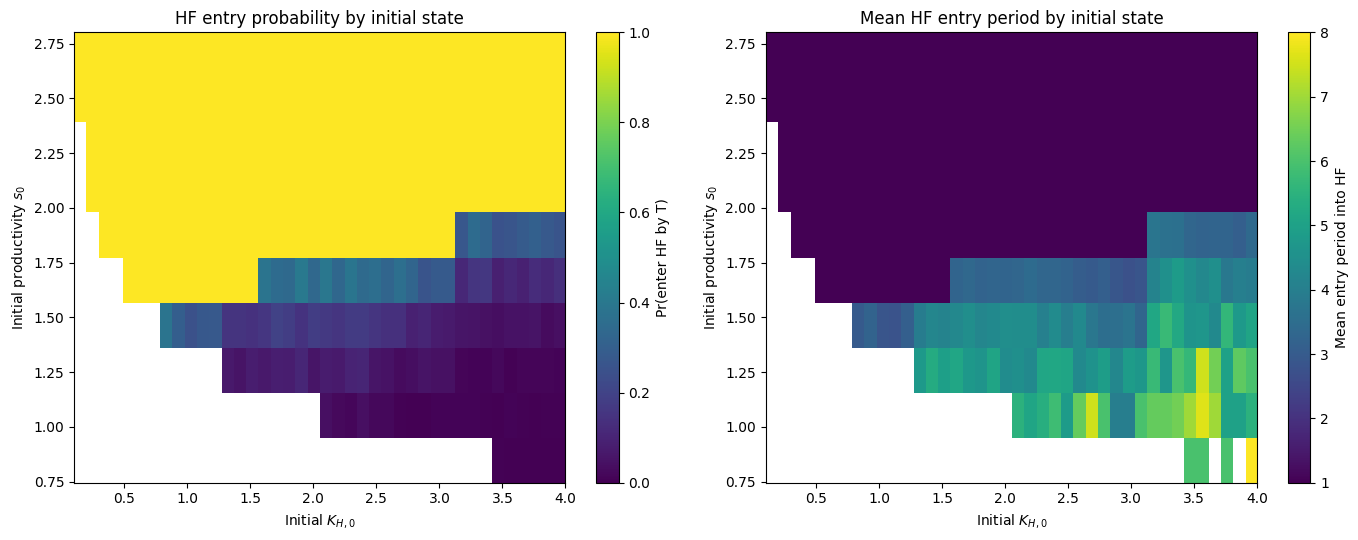

In [80]:
# %%
# -----------------------------
# Build matrices: frictions
# -----------------------------
x_vals_prob, y_vals_prob, Z_prob = make_heatmap_matrix(agg_state_df, "hf_share_ever")
x_vals_time, y_vals_time, Z_time = make_heatmap_matrix(agg_state_df, "mean_entry_period")

if not (np.allclose(x_vals_prob, x_vals_time) and np.allclose(y_vals_prob, y_vals_time)):
    raise ValueError("Baseline probability and timing matrices are not aligned.")

Z_time_masked = np.ma.masked_invalid(Z_time)

# -----------------------------
# Figure 1: baseline heatmaps
# -----------------------------
fig1, axes1 = plt.subplots(1, 2, figsize=(14, 5.5))

im1 = axes1[0].imshow(
    Z_prob,
    origin="lower",
    aspect="auto",
    extent=[x_vals_prob.min(), x_vals_prob.max(), y_vals_prob.min(), y_vals_prob.max()]
)
axes1[0].set_xlabel(r"Initial $K_{H,0}$")
axes1[0].set_ylabel(r"Initial productivity $s_0$")
axes1[0].set_title("HF entry probability by initial state")
fig1.colorbar(im1, ax=axes1[0], label="Pr(enter HF by T)")

im2 = axes1[1].imshow(
    Z_time_masked,
    origin="lower",
    aspect="auto",
    extent=[x_vals_time.min(), x_vals_time.max(), y_vals_time.min(), y_vals_time.max()]
)
axes1[1].set_xlabel(r"Initial $K_{H,0}$")
axes1[1].set_ylabel(r"Initial productivity $s_0$")
axes1[1].set_title("Mean HF entry period by initial state")
fig1.colorbar(im2, ax=axes1[1], label="Mean entry period into HF")

plt.tight_layout()
plt.show()

# Save in Output folder as PNG
fig1.savefig("Output/figure1_heatmaps.png", dpi=300)

## Comparison Frictions vs No frictions
1. HF entry probability by state 
2. Distribution of entry periods among entrants
3. Cumulative entry probability 
4. Hazard rate 

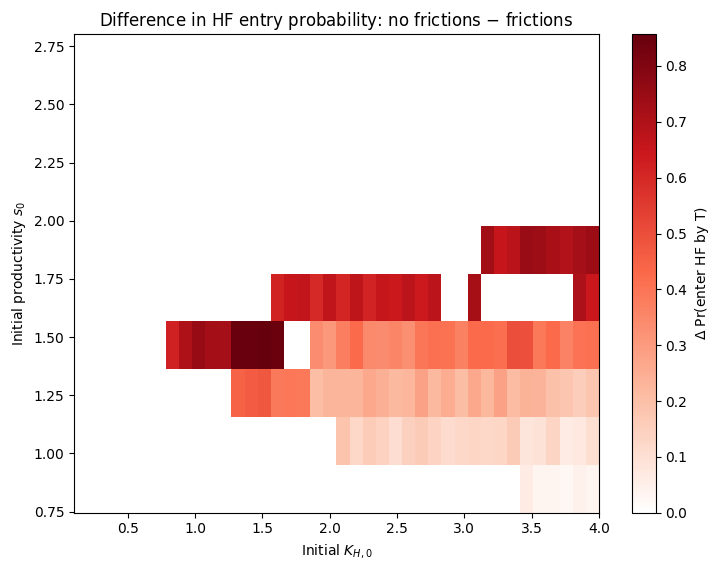

In [81]:
# %%
# -----------------------------
# Build matrices: no frictions
# -----------------------------
x_vals_prob_NF, y_vals_prob_NF, Z_prob_NF = make_heatmap_matrix(agg_state_df_NF, "hf_share_ever")
x_vals_time_NF, y_vals_time_NF, Z_time_NF = make_heatmap_matrix(agg_state_df_NF, "mean_entry_period")

if not (np.allclose(x_vals_prob_NF, x_vals_time_NF) and np.allclose(y_vals_prob_NF, y_vals_time_NF)):
    raise ValueError("No-frictions probability and timing matrices are not aligned.")

if not (np.allclose(x_vals_prob, x_vals_prob_NF) and np.allclose(y_vals_prob, y_vals_prob_NF)):
    raise ValueError("Frictions and no-frictions grids do not match.")

# -----------------------------
# Figure 2: difference heatmap
#   no frictions - frictions
# -----------------------------
Z_diff = Z_prob_NF - Z_prob

reds_from_white = LinearSegmentedColormap.from_list(
    "white_to_red",
    ["white", "#fcbba1", "#fb6a4a", "#cb181d", "#67000d"]
)

fig2, ax2 = plt.subplots(1, 1, figsize=(7.5, 5.8))

im_diff = ax2.imshow(
    Z_diff,
    origin="lower",
    aspect="auto",
    extent=[x_vals_prob.min(), x_vals_prob.max(), y_vals_prob.min(), y_vals_prob.max()],
    cmap=reds_from_white,
    vmin=0.0,
    vmax=np.nanmax(Z_diff)
)

ax2.set_xlabel(r"Initial $K_{H,0}$")
ax2.set_ylabel(r"Initial productivity $s_0$")
ax2.set_title(r"Difference in HF entry probability: no frictions $-$ frictions")

fig2.colorbar(im_diff, ax=ax2, label=r"$\Delta$ Pr(enter HF by T)")

plt.tight_layout()
plt.show()

# Save in Output folder as PNG
fig2.savefig("Output/figure2_difference_heatmap.png", dpi=300)

In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# %%
def build_entry_period_comparison_df(
    summary_df_fric: pd.DataFrame,
    summary_df_nofric: pd.DataFrame,
    label_fric: str = "Frictions",
    label_nofric: str = "No frictions",
) -> pd.DataFrame:
    """
    Keep only firms that ever enter HF and stack the two environments.
    """
    df_fric = summary_df_fric.loc[summary_df_fric["ever_hf"] == 1, ["first_hf_period"]].copy()
    df_fric["regime_case"] = label_fric

    df_nofric = summary_df_nofric.loc[summary_df_nofric["ever_hf"] == 1, ["first_hf_period"]].copy()
    df_nofric["regime_case"] = label_nofric

    out = pd.concat([df_fric, df_nofric], axis=0, ignore_index=True)
    out["first_hf_period"] = out["first_hf_period"].astype(int)
    return out


def plot_side_by_side_entry_hist(
    entry_df: pd.DataFrame,
    ax,
    title: str,
    decimals: int = 2,
):
    counts = (
        entry_df
        .groupby(["regime_case", "first_hf_period"], as_index=False)
        .size()
        .rename(columns={"size": "n"})
    )
    counts["share"] = counts.groupby("regime_case")["n"].transform(lambda x: x / x.sum())

    pivot = (
        counts.pivot(index="first_hf_period", columns="regime_case", values="share")
        .fillna(0.0)
        .sort_index()
    )

    periods = pivot.index.to_numpy(dtype=int)
    cases = list(pivot.columns)

    if len(cases) != 2:
        raise ValueError("Expected exactly two groups in regime_case.")

    x = np.arange(len(periods))
    width = 0.38

    bars1 = ax.bar(x - width / 2, pivot[cases[0]].to_numpy(), width=width, label=cases[0])
    bars2 = ax.bar(x + width / 2, pivot[cases[1]].to_numpy(), width=width, label=cases[1])

    for bars in [bars1, bars2]:
        for b in bars:
            h = b.get_height()
            if h > 0:
                ax.text(
                    b.get_x() + b.get_width() / 2,
                    h,
                    f"{h:.{decimals}f}",
                    ha="center",
                    va="bottom",
                    fontsize=8,
                )

    ax.set_xticks(x)
    ax.set_xticklabels(periods)
    ax.set_xlabel("First period of HF entry")
    ax.set_ylabel("Share of entrants")
    ax.set_title(title)
    ax.grid(alpha=0.2, axis="y")


def plot_entry_period_distribution_full_and_restricted(
    summary_df: pd.DataFrame,
    summary_df_NF: pd.DataFrame,
    agg_state_df: pd.DataFrame,
    label_fric: str = "Frictions",
    label_nofric: str = "No frictions",
):
    entry_compare_full = build_entry_period_comparison_df(
        summary_df_fric=summary_df,
        summary_df_nofric=summary_df_NF,
        label_fric=label_fric,
        label_nofric=label_nofric,
    )

    keep_s_idx = get_s0_idx_not_all_one(agg_state_df, value_col="hf_share_ever")

    summary_df_r = summary_df[summary_df["s0_idx"].isin(keep_s_idx)].copy()
    summary_df_NF_r = summary_df_NF[summary_df_NF["s0_idx"].isin(keep_s_idx)].copy()

    entry_compare_restricted = build_entry_period_comparison_df(
        summary_df_fric=summary_df_r,
        summary_df_nofric=summary_df_NF_r,
        label_fric=label_fric,
        label_nofric=label_nofric,
    )

    fig, axes = plt.subplots(1, 2, figsize=(15, 5.4), sharey=True)

    plot_side_by_side_entry_hist(
        entry_compare_full,
        ax=axes[0],
        title="All entrants",
    )

    plot_side_by_side_entry_hist(
        entry_compare_restricted,
        ax=axes[1],
        title=r"Restricted: exclude $s_0$ rows with $\Pr(HF)=1$ for all $K_H$",
    )

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="lower center", bbox_to_anchor=(0.5, -0.03), ncol=2, frameon=False)
    fig.suptitle("Distribution of HF entry periods among entrants", y=1.02)
    plt.tight_layout(rect=[0, 0.05, 1, 0.95])
    plt.show()

    return keep_s_idx, entry_compare_full, entry_compare_restricted


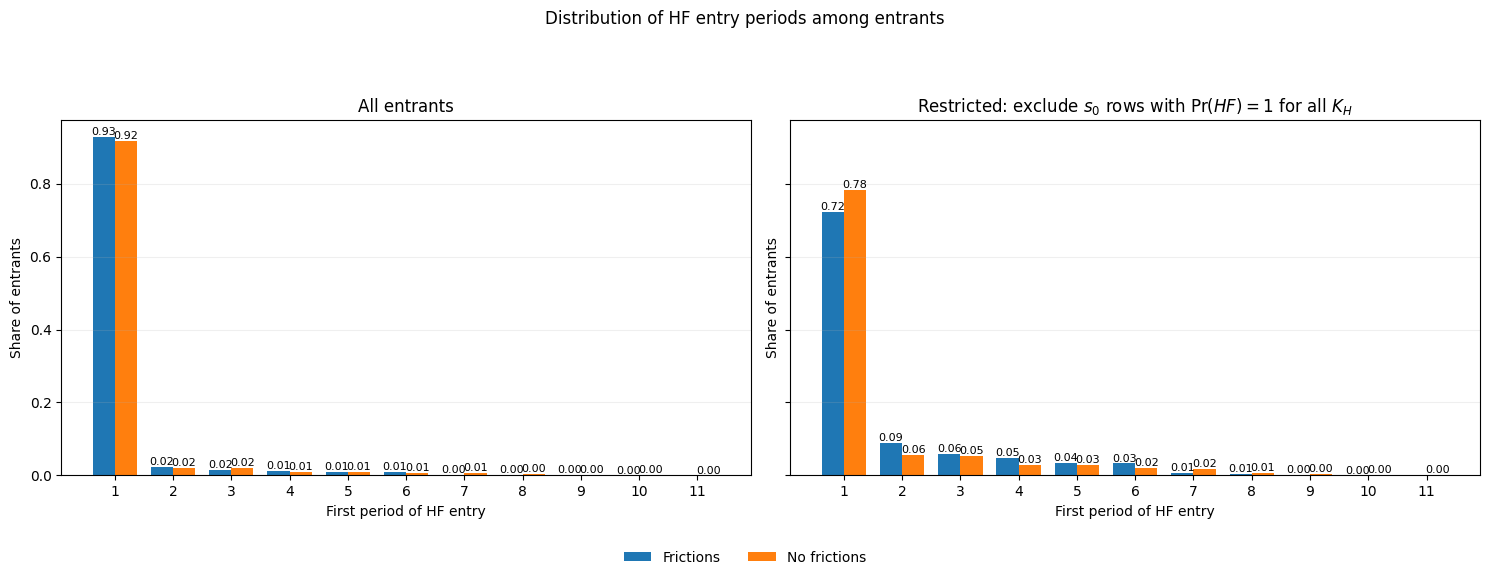

In [47]:
# %%
keep_s_idx, entry_compare_full, entry_compare_restricted = plot_entry_period_distribution_full_and_restricted(
    summary_df=summary_df,
    summary_df_NF=summary_df_NF,
    agg_state_df=agg_state_df,
    label_fric="Frictions",
    label_nofric="No frictions",
)

In [ ]:
# %%
def build_cumulative_hf_entry_df(
    summary_df: pd.DataFrame,
    n_periods: int,
    label: str,
) -> pd.DataFrame:
    first_hf = summary_df["first_hf_period"].to_numpy(dtype=float)
    ever_hf = ~np.isnan(first_hf)

    rows = []
    for t in range(n_periods):
        cum_share = np.mean(ever_hf & (first_hf <= t))
        rows.append({
            "period": t,
            "cum_hf_share": float(cum_share),
            "case": label,
        })

    return pd.DataFrame(rows)

def plot_cumulative_hf_entry_comparison(
    summary_df_fric: pd.DataFrame,
    summary_df_nofric: pd.DataFrame,
    n_periods: int,
    label_fric: str = "Frictions",
    label_nofric: str = "No frictions",
    title: str = "Cumulative share of firms that have entered HF",
) -> pd.DataFrame:
    df_fric = build_cumulative_hf_entry_df(summary_df_fric, n_periods, label_fric)
    df_nofric = build_cumulative_hf_entry_df(summary_df_nofric, n_periods, label_nofric)
    plot_df = pd.concat([df_fric, df_nofric], axis=0, ignore_index=True)

    fig, ax = plt.subplots(figsize=(8.5, 5.2))

    for label, sub in plot_df.groupby("case"):
        sub = sub.sort_values("period")
        ax.plot(
            sub["period"],
            sub["cum_hf_share"],
            marker="o",
            linewidth=2,
            label=label,
        )

    ax.set_xlabel("Period")
    ax.set_ylabel("Cumulative share entered HF")
    ax.set_title(title)
    ax.legend(frameon=False)
    ax.grid(alpha=0.2)

    plt.tight_layout()
    plt.show()

    return plot_df

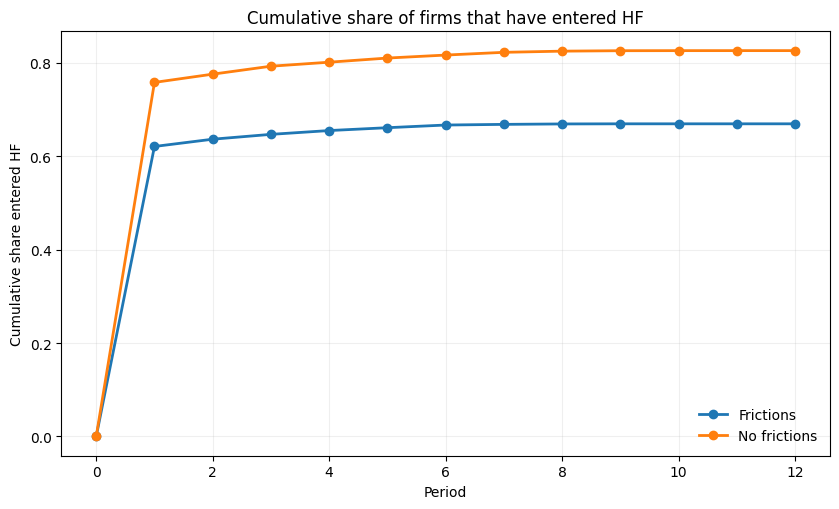

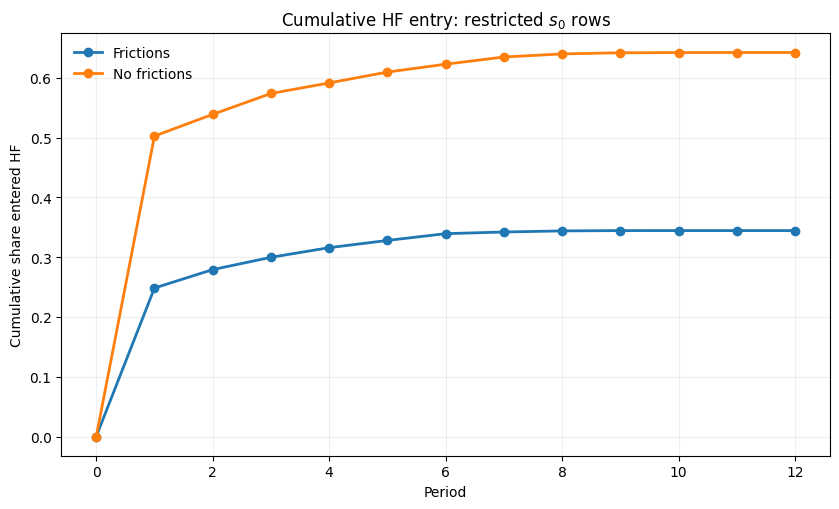

In [48]:
# %%
cum_entry_df = plot_cumulative_hf_entry_comparison(
    summary_df_fric=summary_df,
    summary_df_nofric=summary_df_NF,
    n_periods=int(long_df["t"].max()) + 1,
    label_fric="Frictions",
    label_nofric="No frictions",
)

keep_s_idx = get_s0_idx_not_all_one(agg_state_df, value_col="hf_share_ever")

summary_df_r = summary_df[summary_df["s0_idx"].isin(keep_s_idx)].copy()
summary_df_NF_r = summary_df_NF[summary_df_NF["s0_idx"].isin(keep_s_idx)].copy()

cum_entry_df_r = plot_cumulative_hf_entry_comparison(
    summary_df_fric=summary_df_r,
    summary_df_nofric=summary_df_NF_r,
    n_periods=int(long_df["t"].max()) + 1,
    label_fric="Frictions",
    label_nofric="No frictions",
    title=r"Cumulative HF entry: restricted $s_0$ rows",
)

In [49]:
# %%
def build_hf_hazard_df(
    summary_df: pd.DataFrame,
    n_periods: int,
    label: str,
) -> pd.DataFrame:
    """
    Discrete-time hazard of first HF entry:
        h(t) = Pr(T = t | T >= t)
    """
    first_hf = summary_df["first_hf_period"].to_numpy(dtype=float)

    rows = []
    for t in range(n_periods):
        at_risk = np.sum(np.isnan(first_hf) | (first_hf >= t))
        enter_now = np.sum(first_hf == t)

        hazard = np.nan if at_risk == 0 else enter_now / at_risk

        rows.append({
            "period": t,
            "at_risk": int(at_risk),
            "enter_now": int(enter_now),
            "hazard": float(hazard) if at_risk > 0 else np.nan,
            "case": label,
        })

    return pd.DataFrame(rows)


def plot_hf_hazard_comparison(
    summary_df_fric: pd.DataFrame,
    summary_df_nofric: pd.DataFrame,
    n_periods: int,
    label_fric: str = "Frictions",
    label_nofric: str = "No frictions",
    title: str = "Hazard of first HF entry",
    annotate: bool = False,
) -> pd.DataFrame:
    df_fric = build_hf_hazard_df(summary_df_fric, n_periods, label_fric)
    df_nofric = build_hf_hazard_df(summary_df_nofric, n_periods, label_nofric)
    hazard_df = pd.concat([df_fric, df_nofric], axis=0, ignore_index=True)

    fig, ax = plt.subplots(figsize=(8.5, 5.2))

    for label, sub in hazard_df.groupby("case"):
        sub = sub.sort_values("period")
        ax.plot(
            sub["period"],
            sub["hazard"],
            marker="o",
            linewidth=2,
            label=label,
        )

        if annotate:
            for _, row in sub.iterrows():
                h = row["hazard"]
                if pd.notna(h) and h > 0:
                    ax.text(
                        row["period"],
                        h,
                        f"{h:.2f}",
                        ha="center",
                        va="bottom",
                        fontsize=8,
                    )

    ax.set_xlabel("Period")
    ax.set_ylabel("Hazard of HF entry")
    ax.set_title(title)
    ax.legend(frameon=False)
    ax.grid(alpha=0.2)
    plt.tight_layout()
    plt.show()

    return hazard_df

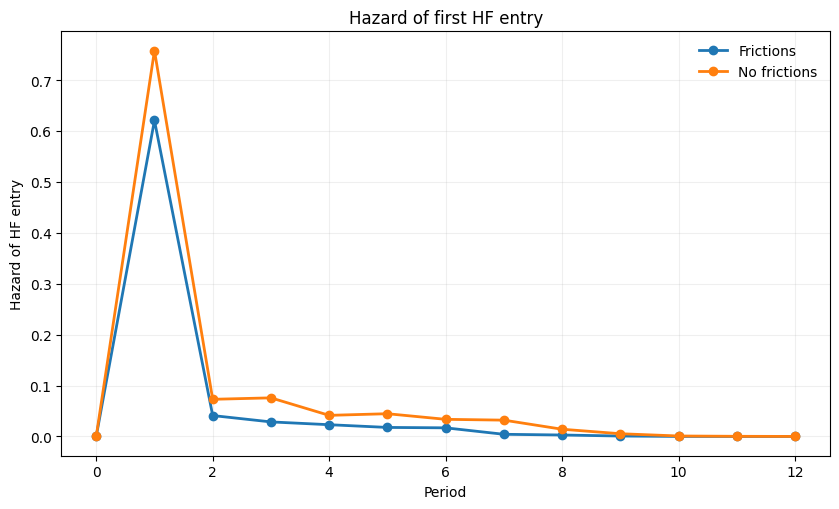

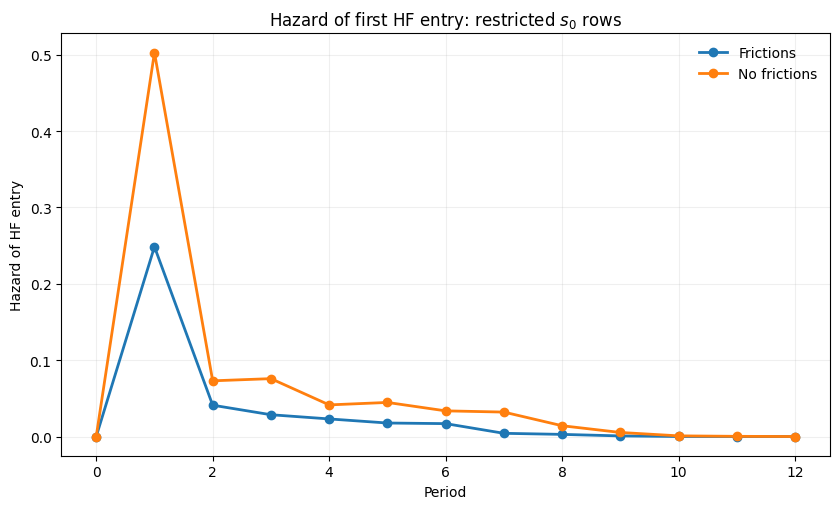

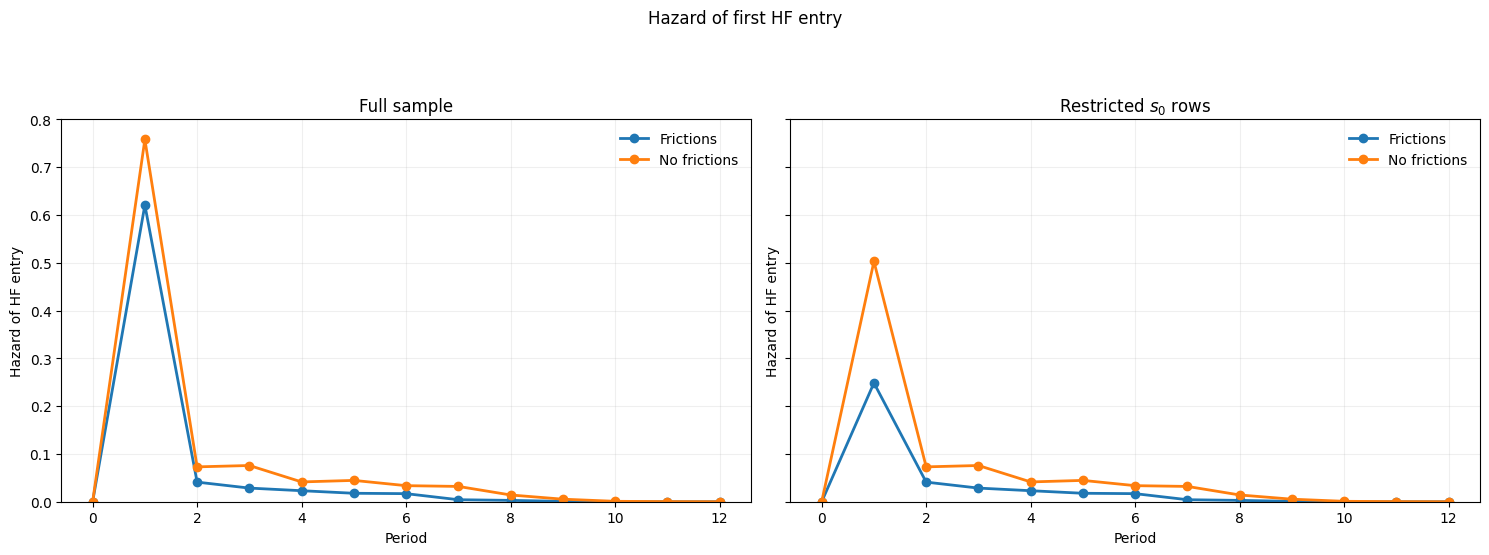

In [85]:
hazard_df = plot_hf_hazard_comparison(
    summary_df_fric=summary_df,
    summary_df_nofric=summary_df_NF,
    n_periods=model_stoch["n_periods"],
    label_fric="Frictions",
    label_nofric="No frictions",
    annotate=False
)

def get_s0_idx_not_all_one(
    agg_state_df: pd.DataFrame,
    value_col: str = "hf_share_ever",
    tol: float = 1e-12,
) -> list[int]:
    keep_s_idx = (
        agg_state_df.groupby("s0_idx")[value_col]
        .apply(lambda x: not np.all(np.isclose(x.to_numpy(dtype=float), 1.0, atol=tol)))
    )
    return keep_s_idx[keep_s_idx].index.tolist()

keep_s_idx = get_s0_idx_not_all_one(agg_state_df)

summary_df_r = summary_df[summary_df["s0_idx"].isin(keep_s_idx)].copy()
summary_df_NF_r = summary_df_NF[summary_df_NF["s0_idx"].isin(keep_s_idx)].copy()

hazard_df_r = plot_hf_hazard_comparison(
    summary_df_fric=summary_df_r,
    summary_df_nofric=summary_df_NF_r,
    n_periods=model_stoch["n_periods"],
    label_fric="Frictions",
    label_nofric="No frictions",
    title=r"Hazard of first HF entry: restricted $s_0$ rows",
)

# Plot in a 1*2 figure on a Y scale from 0-0.8 for better compariso
# %%
def plot_hf_hazard_comparison_full_and_restricted(
    summary_df: pd.DataFrame,
    summary_df_NF: pd.DataFrame,
    agg_state_df: pd.DataFrame,
    n_periods: int,
    label_fric: str = "Frictions",
    label_nofric: str = "No frictions",
    y_max: float = 0.8,
):
    keep_s_idx = get_s0_idx_not_all_one(agg_state_df)

    summary_df_r = summary_df[summary_df["s0_idx"].isin(keep_s_idx)].copy()
    summary_df_NF_r = summary_df_NF[summary_df_NF["s0_idx"].isin(keep_s_idx)].copy()

    hazard_full = pd.concat(
        [
            build_hf_hazard_df(summary_df, n_periods, label_fric),
            build_hf_hazard_df(summary_df_NF, n_periods, label_nofric),
        ],
        axis=0,
        ignore_index=True,
    )

    hazard_restricted = pd.concat(
        [
            build_hf_hazard_df(summary_df_r, n_periods, label_fric),
            build_hf_hazard_df(summary_df_NF_r, n_periods, label_nofric),
        ],
        axis=0,
        ignore_index=True,
    )

    fig, axes = plt.subplots(1, 2, figsize=(15, 5.4), sharey=True)

    for label, sub in hazard_full.groupby("case"):
        sub = sub.sort_values("period")
        axes[0].plot(
            sub["period"],
            sub["hazard"],
            marker="o",
            linewidth=2,
            label=label,
        )

    for label, sub in hazard_restricted.groupby("case"):
        sub = sub.sort_values("period")
        axes[1].plot(
            sub["period"],
            sub["hazard"],
            marker="o",
            linewidth=2,
            label=label,
        )

    axes[0].set_title("Full sample")
    axes[1].set_title(r"Restricted $s_0$ rows")

    for ax in axes:
        ax.set_xlabel("Period")
        ax.set_ylabel("Hazard of HF entry")
        ax.set_ylim(0, y_max)
        ax.grid(alpha=0.2)
        ax.legend(frameon=False)

    fig.suptitle("Hazard of first HF entry", y=1.02)
    plt.tight_layout(rect=[0, 0, 1, 0.95])

    return fig, axes, hazard_full, hazard_restricted

fig, axes, hazard_full, hazard_restricted = plot_hf_hazard_comparison_full_and_restricted(
    summary_df=summary_df,
    summary_df_NF=summary_df_NF,
    agg_state_df=agg_state_df,
    n_periods=model_stoch["n_periods"],
    label_fric="Frictions",
    label_nofric="No frictions",
    y_max=0.8,
)

fig.savefig("Output/hazard_full_vs_restricted.png", dpi=300, bbox_inches="tight")
plt.show()





###  Pick 3 inital states
1. Low probability of entering HF
2. 50% probability of enter HF
3. High probability of entering HF 

In [71]:
# %%
def pick_representative_states(
    agg_state_df: pd.DataFrame,
    targets=(0.10, 0.50, 0.90),
    labels=("low", "middle", "high"),
) -> pd.DataFrame:
    """
    Pick representative initial states based on hf_share_ever.
    """
    if len(targets) != len(labels):
        raise ValueError("targets and labels must have the same length.")

    df = agg_state_df.copy()
    chosen_rows = []
    used_state_ids = set()

    for target, label in zip(targets, labels):
        cand = df.loc[~df["state_id"].isin(used_state_ids)].copy()
        cand["distance_to_target"] = (cand["hf_share_ever"] - target).abs()

        cand = cand.sort_values(
            ["distance_to_target", "s0", "KH0"],
            ascending=[True, True, True]
        )

        row = cand.iloc[0].copy()
        row["target_prob"] = target
        row["label"] = label

        chosen_rows.append(row)
        used_state_ids.add(int(row["state_id"]))

    out = pd.DataFrame(chosen_rows).reset_index(drop=True)
    return out[
        [
            "label",
            "target_prob",
            "state_id",
            "s0_idx",
            "s0",
            "KH0",
            "KF0",
            "hf_share_ever",
            "mean_entry_period",
            "stay_x_share",
            "initial_profit_X",
        ]
    ]


selected_states = pick_representative_states(agg_state_df)
print(selected_states)

    label  target_prob  state_id  s0_idx        s0  KH0  KF0  hf_share_ever  \
0     low          0.1      36.0     7.0  1.000000  2.3  0.0       0.100000   
1  middle          0.5     101.0     9.0  1.342196  1.9  0.0       0.403333   
2    high          0.9      87.0     9.0  1.342196  0.5  0.0       1.000000   

   mean_entry_period  stay_x_share  initial_profit_X  
0           5.133333      0.900000          0.361946  
1           3.280992      0.596667          0.581138  
2           1.000000      0.000000          0.257291  


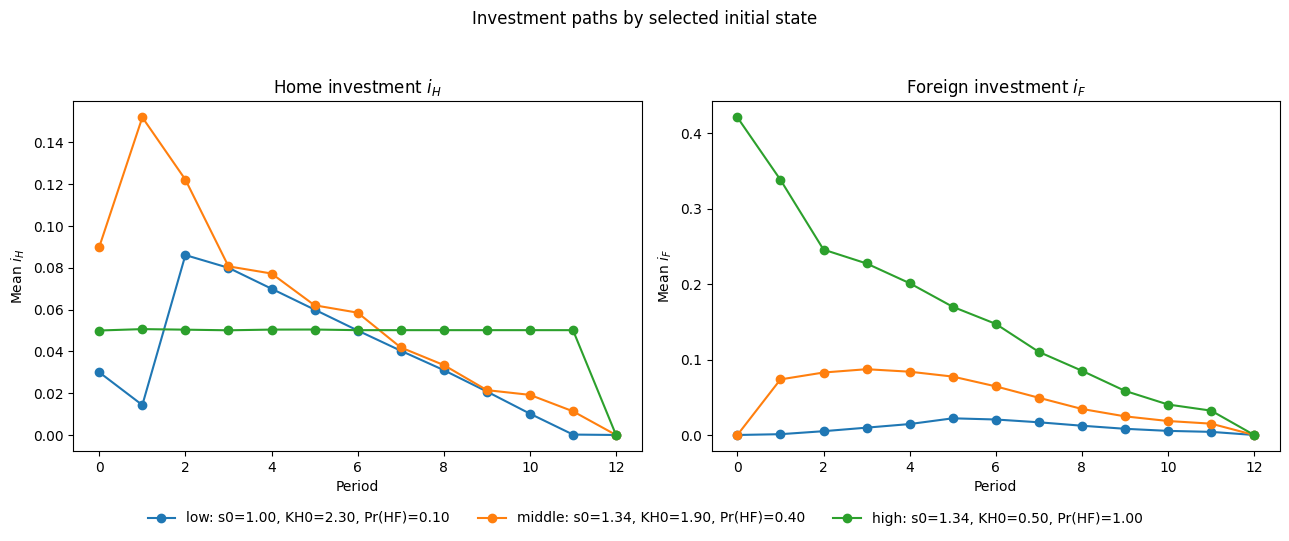

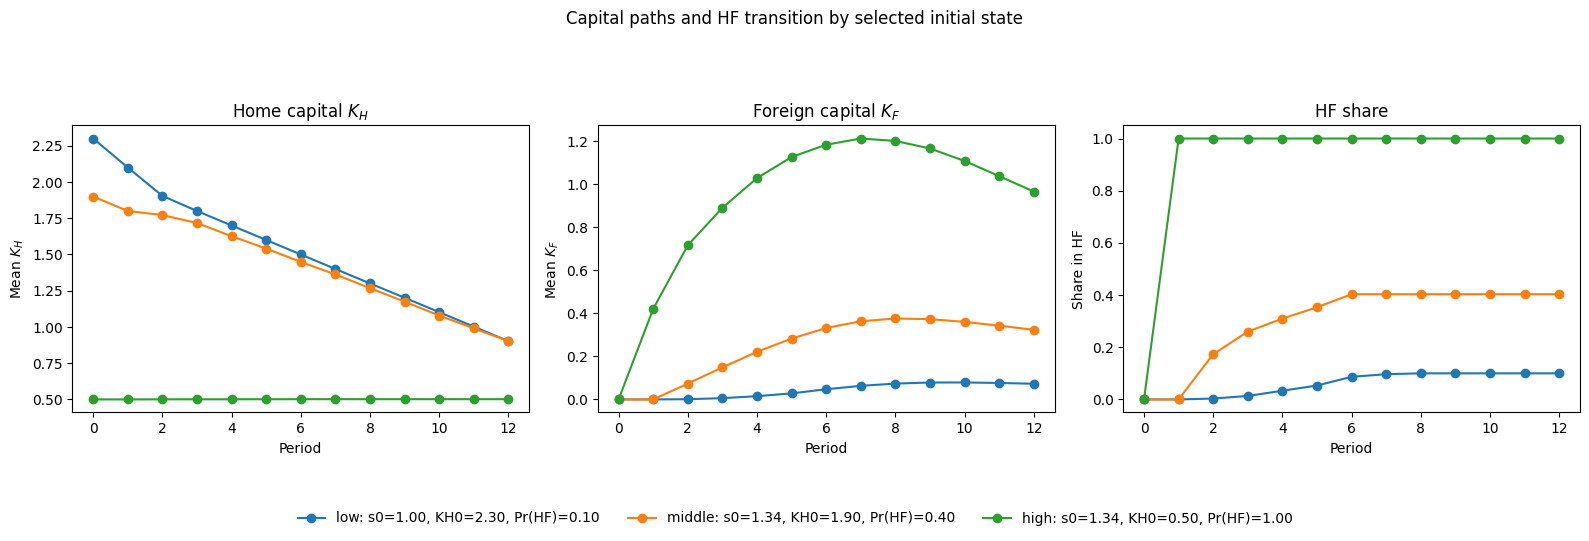

In [72]:
# %%
def plot_selected_state_figures_from_long_df(
    long_df: pd.DataFrame,
    selected_states: pd.DataFrame,
) -> None:
    """
    Use the canonical long panel directly for mean path plots.
    """
    fig1, axes1 = plt.subplots(1, 2, figsize=(13, 4.8))

    for _, row in selected_states.iterrows():
        state_id = int(row["state_id"])
        label = str(row["label"])

        sub = (
            long_df.loc[long_df["state_id"] == state_id]
            .groupby("t", as_index=False)
            .agg(
                mean_iH=("iH_t", "mean"),
                mean_iF=("iF_t", "mean"),
                mean_KH=("KH_t", "mean"),
                mean_KF=("KF_t", "mean"),
                hf_share=("is_hf_t", "mean"),
            )
            .sort_values("t")
        )

        legend_label = (
            f"{label}: s0={row['s0']:.2f}, KH0={row['KH0']:.2f}, "
            f"Pr(HF)={row['hf_share_ever']:.2f}"
        )

        axes1[0].plot(sub["t"], sub["mean_iH"], marker="o", label=legend_label)
        axes1[1].plot(sub["t"], sub["mean_iF"], marker="o", label=legend_label)

    axes1[0].set_xlabel("Period")
    axes1[0].set_ylabel(r"Mean $i_H$")
    axes1[0].set_title(r"Home investment $i_H$")

    axes1[1].set_xlabel("Period")
    axes1[1].set_ylabel(r"Mean $i_F$")
    axes1[1].set_title(r"Foreign investment $i_F$")

    handles1, labels1 = axes1[0].get_legend_handles_labels()
    fig1.legend(handles1, labels1, loc="lower center", bbox_to_anchor=(0.5, -0.06),
                ncol=min(3, len(labels1)), frameon=False)
    fig1.suptitle("Investment paths by selected initial state", y=1.04)
    plt.tight_layout()
    plt.show()

    fig2, axes2 = plt.subplots(1, 3, figsize=(16, 4.8))

    for _, row in selected_states.iterrows():
        state_id = int(row["state_id"])
        label = str(row["label"])

        sub = (
            long_df.loc[long_df["state_id"] == state_id]
            .groupby("t", as_index=False)
            .agg(
                mean_KH=("KH_t", "mean"),
                mean_KF=("KF_t", "mean"),
                hf_share=("is_hf_t", "mean"),
            )
            .sort_values("t")
        )

        legend_label = (
            f"{label}: s0={row['s0']:.2f}, KH0={row['KH0']:.2f}, "
            f"Pr(HF)={row['hf_share_ever']:.2f}"
        )

        axes2[0].plot(sub["t"], sub["mean_KH"], marker="o", label=legend_label)
        axes2[1].plot(sub["t"], sub["mean_KF"], marker="o", label=legend_label)
        axes2[2].plot(sub["t"], sub["hf_share"], marker="o", label=legend_label)

    axes2[0].set_xlabel("Period")
    axes2[0].set_ylabel(r"Mean $K_H$")
    axes2[0].set_title(r"Home capital $K_H$")

    axes2[1].set_xlabel("Period")
    axes2[1].set_ylabel(r"Mean $K_F$")
    axes2[1].set_title(r"Foreign capital $K_F$")

    axes2[2].set_xlabel("Period")
    axes2[2].set_ylabel("Share in HF")
    axes2[2].set_title("HF share")

    handles2, labels2 = axes2[0].get_legend_handles_labels()
    fig2.legend(handles2, labels2, loc="lower center", bbox_to_anchor=(0.5, -0.06),
                ncol=min(3, len(labels2)), frameon=False)
    fig2.suptitle("Capital paths and HF transition by selected initial state", y=1.04)
    plt.tight_layout(rect=[0, 0.08, 1, 0.95])
    plt.show()

    # %%
plot_selected_state_figures_from_long_df(
    long_df=long_df,
    selected_states=selected_states,
)

## Distrbutions in final period
1. Create a distribution of the productivity by state 
2. Create a distribution of the caqpital stock by state

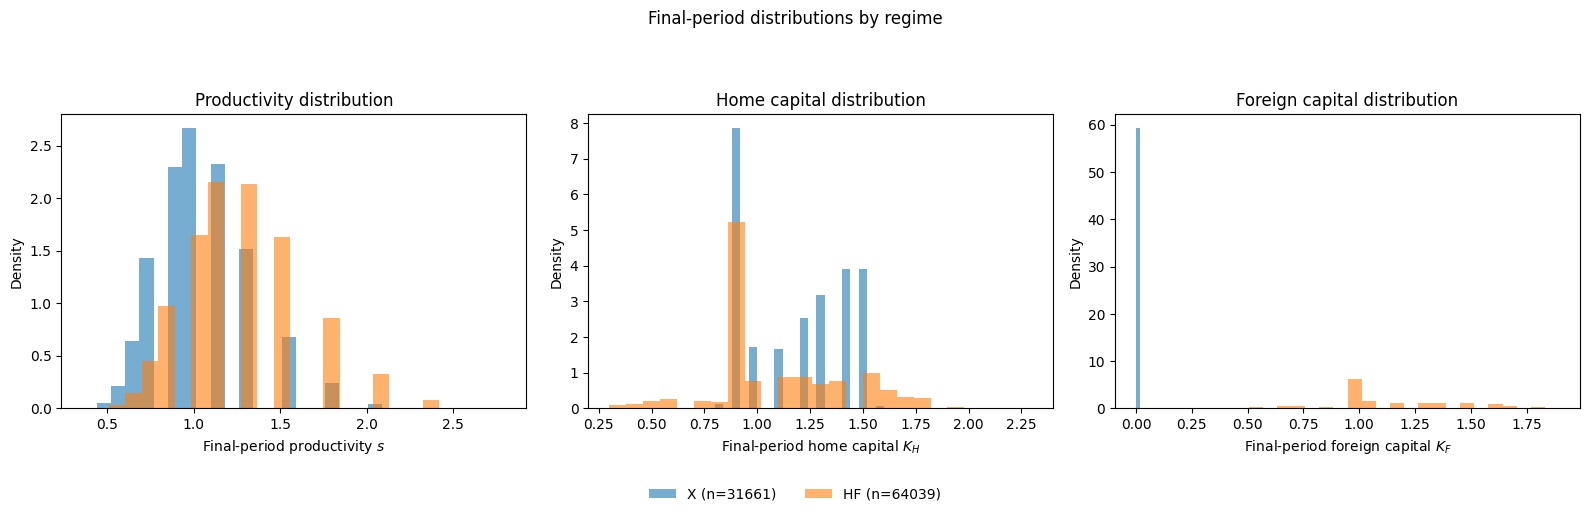

In [53]:
# %%
def build_final_period_distribution_df_from_master(
    long_df: pd.DataFrame,
) -> pd.DataFrame:
    """
    Build final-period distribution DataFrame from the canonical long panel.
    """
    final_t = int(long_df["t"].max())

    final_df = (
        long_df.loc[long_df["t"] == final_t, [
            "state_id", "firm_id", "s0", "KH0", "KF0",
            "mode_t", "s_t", "KH_t", "KF_t"
        ]]
        .rename(columns={
            "mode_t": "final_mode",
            "s_t": "final_s",
            "KH_t": "final_KH",
            "KF_t": "final_KF",
        })
        .reset_index(drop=True)
    )

    return final_df


def plot_final_period_distributions(final_df: pd.DataFrame, bins: int = 25) -> None:
    df_X = final_df.loc[final_df["final_mode"] == "X"].copy()
    df_HF = final_df.loc[final_df["final_mode"] == "HF"].copy()

    if len(df_X) == 0:
        raise ValueError("No firms end in regime X.")
    if len(df_HF) == 0:
        raise ValueError("No firms end in regime HF.")

    fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))

    axes[0].hist(df_X["final_s"], bins=bins, density=True, alpha=0.6, label=f"X (n={len(df_X)})")
    axes[0].hist(df_HF["final_s"], bins=bins, density=True, alpha=0.6, label=f"HF (n={len(df_HF)})")
    axes[0].set_xlabel(r"Final-period productivity $s$")
    axes[0].set_ylabel("Density")
    axes[0].set_title("Productivity distribution")

    axes[1].hist(df_X["final_KH"], bins=bins, density=True, alpha=0.6, label=f"X (n={len(df_X)})")
    axes[1].hist(df_HF["final_KH"], bins=bins, density=True, alpha=0.6, label=f"HF (n={len(df_HF)})")
    axes[1].set_xlabel(r"Final-period home capital $K_H$")
    axes[1].set_ylabel("Density")
    axes[1].set_title(r"Home capital distribution")

    axes[2].hist(df_X["final_KF"], bins=bins, density=True, alpha=0.6, label=f"X (n={len(df_X)})")
    axes[2].hist(df_HF["final_KF"], bins=bins, density=True, alpha=0.6, label=f"HF (n={len(df_HF)})")
    axes[2].set_xlabel(r"Final-period foreign capital $K_F$")
    axes[2].set_ylabel("Density")
    axes[2].set_title(r"Foreign capital distribution")

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="lower center", bbox_to_anchor=(0.5, -0.03), ncol=2, frameon=False)
    fig.suptitle("Final-period distributions by regime", y=1.02)
    plt.tight_layout(rect=[0, 0.06, 1, 0.95])
    plt.show()

    # %%
final_df = build_final_period_distribution_df_from_master(long_df)
plot_final_period_distributions(final_df, bins=25)

# Exporting while being a multinational 
Below I investigate how many firms 
1. Continue exporting when they entered HF and whether this decreases over time. 
    - This is in line with the theoretical predictions that firms dont have a capital stock yet when they enter the foreign country. 

2. What are the capital paths for 
    - firms which enter HF and dont export initallu
    - firms which enter HF and do export initally

In [59]:
# %%
print("Share of HF entrants that still export at entry (frictions):")
print(summary_df["coexist_at_hf_entry"].mean())

print("\nShare of HF entrants for which exports later die out (frictions):")
print(summary_df["export_dies_after_hf_entry"].mean())

print("\nShare of HF entrants that still export at entry (no frictions):")
print(summary_df_NF["coexist_at_hf_entry"].mean())

print("\nShare of HF entrants for which exports later die out (no frictions):")
print(summary_df_NF["export_dies_after_hf_entry"].mean())

Share of HF entrants that still export at entry (frictions):
0.6370506854876488

Share of HF entrants for which exports later die out (frictions):
0.4218181818181818

Share of HF entrants that still export at entry (no frictions):
0.031909317258550646

Share of HF entrants for which exports later die out (no frictions):
0.026352813852813853


### Do firms in HF still export and does exporting die out

In [86]:
# %%
def build_hf_coexistence_calendar_df(long_df: pd.DataFrame, label: str) -> pd.DataFrame:
    """
    Calendar-time objects among firms that are in HF in period t.
    """
    df = long_df.loc[long_df["is_hf_t"] == 1].copy()

    if len(df) == 0:
        return pd.DataFrame(columns=[
            "t", "n_hf", "share_hf_still_exporting",
            "mean_export_share_foreign", "mean_psi_over_GammaX", "case"
        ])

    out = (
        df.groupby("t", as_index=False)
          .agg(
              n_hf=("firm_id", "count"),
              share_hf_still_exporting=("is_exporting_in_hf_t", "mean"),
              mean_export_share_foreign=("export_share_foreign_t", "mean"),
              mean_psi_over_GammaX=("psi_over_GammaX_t", "mean"),
          )
    )
    out["case"] = label
    return out


def build_hf_coexistence_event_df(long_df: pd.DataFrame, label: str) -> pd.DataFrame:
    """
    Event-time objects since first HF entry, conditional on being in HF at that event time.
    """
    rows = []

    for (state_id, firm_id), sub in long_df.groupby(["state_id", "firm_id"]):
        sub = sub.sort_values("t").reset_index(drop=True)
        hf = sub.loc[sub["is_hf_t"] == 1].copy()

        if len(hf) == 0:
            continue

        entry_t = int(hf["t"].min())

        for _, r in hf.iterrows():
            rows.append({
                "state_id": state_id,
                "firm_id": firm_id,
                "event_time": int(r["t"] - entry_t),
                "is_exporting_in_hf_t": int(r["is_exporting_in_hf_t"]),
                "export_share_foreign_t": float(r["export_share_foreign_t"]),
                "psi_over_GammaX_t": float(r["psi_over_GammaX_t"]),
                "case": label,
            })

    if len(rows) == 0:
        return pd.DataFrame(columns=[
            "event_time", "n_obs", "share_hf_still_exporting",
            "mean_export_share_foreign", "mean_psi_over_GammaX", "case"
        ])

    df = pd.DataFrame(rows)

    out = (
        df.groupby(["case", "event_time"], as_index=False)
          .agg(
              n_obs=("firm_id", "count"),
              share_hf_still_exporting=("is_exporting_in_hf_t", "mean"),
              mean_export_share_foreign=("export_share_foreign_t", "mean"),
              mean_psi_over_GammaX=("psi_over_GammaX_t", "mean"),
          )
    )
    return out


def plot_hf_coexistence_dynamics_separate(
    long_df_fric: pd.DataFrame,
    long_df_nofric: pd.DataFrame | None = None,
    label_fric: str = "Frictions",
    label_nofric: str = "No frictions",
):
    cal_fric = build_hf_coexistence_calendar_df(long_df_fric, label_fric)
    evt_fric = build_hf_coexistence_event_df(long_df_fric, label_fric)

    frames_cal = [cal_fric]
    frames_evt = [evt_fric]

    if long_df_nofric is not None:
        frames_cal.append(build_hf_coexistence_calendar_df(long_df_nofric, label_nofric))
        frames_evt.append(build_hf_coexistence_event_df(long_df_nofric, label_nofric))

    cal_df = pd.concat(frames_cal, ignore_index=True)
    evt_df = pd.concat(frames_evt, ignore_index=True)

    # Figure 1: calendar time
    fig1, ax1 = plt.subplots(figsize=(7.2, 5.2))

    for label, sub in cal_df.groupby("case"):
        sub = sub.sort_values("t")
        ax1.plot(
            sub["t"],
            sub["share_hf_still_exporting"],
            marker="o",
            linewidth=2,
            label=label,
        )

    ax1.set_xlabel("Calendar period")
    ax1.set_ylabel(r"Pr($q_X>0 \mid HF_t$)")
    ax1.set_title("Share of HF firms that still export")
    ax1.grid(alpha=0.2)
    ax1.legend(frameon=False)
    plt.tight_layout()
    plt.show()

    # Figure 2: event time
    fig2, ax2 = plt.subplots(figsize=(7.2, 5.2))

    for label, sub in evt_df.groupby("case"):
        sub = sub.sort_values("event_time")
        ax2.plot(
            sub["event_time"],
            sub["share_hf_still_exporting"],
            marker="o",
            linewidth=2,
            label=label,
        )

    ax2.set_xlabel("Event time since first HF entry")
    ax2.set_ylabel(r"Pr($q_X>0 \mid HF,$ event time)")
    ax2.set_title("HF coexistence after entry")
    ax2.grid(alpha=0.2)
    ax2.legend(frameon=False)
    plt.tight_layout()
    plt.show()

    return fig1, fig2, cal_df, evt_df

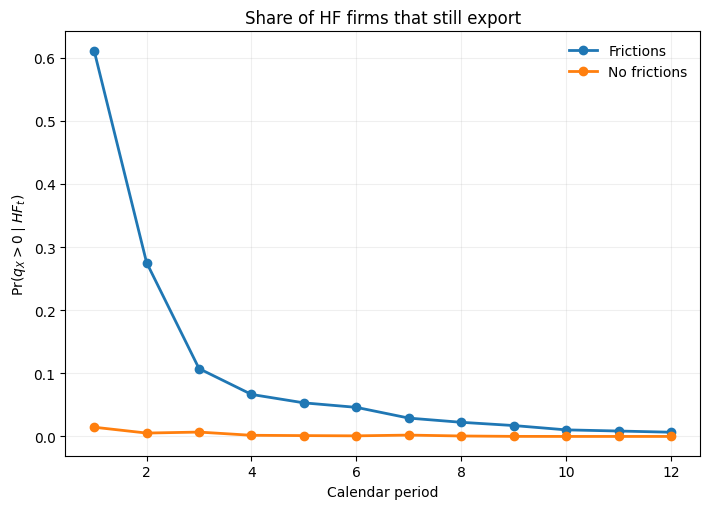

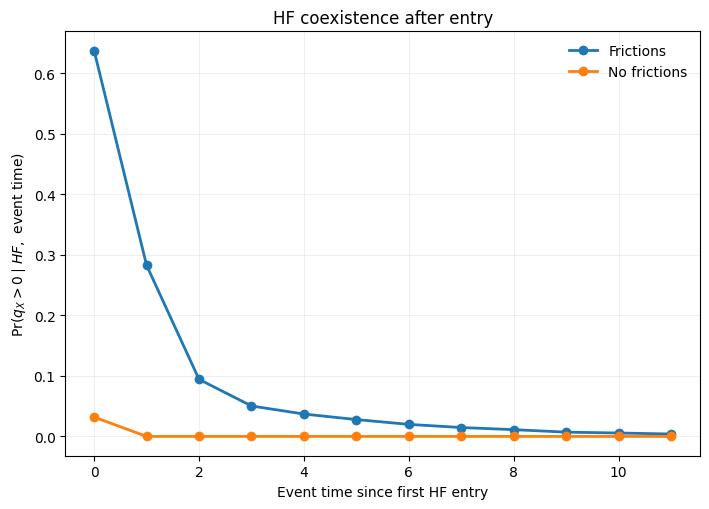

In [88]:
fig1, fig2, cal_df, evt_df = plot_hf_coexistence_dynamics_separate(
    long_df_fric=long_df,
    long_df_nofric=long_df_NF,
    label_fric="Frictions",
    label_nofric="No frictions",
)

# Only save the second plot
fig2.savefig("output/hf_coexistence_after_entry.png", dpi=300, bbox_inches="tight")

coexistence is not a generic feature of the static profit block alone, but really a dynamic consequence of gradual capital adjustment. The left figure whos the share of HF firms that still export irrespective of when the entered. The right figure conditions on entry time. Thefefore it has a less fat tail as there are also firms entering in later periods. 

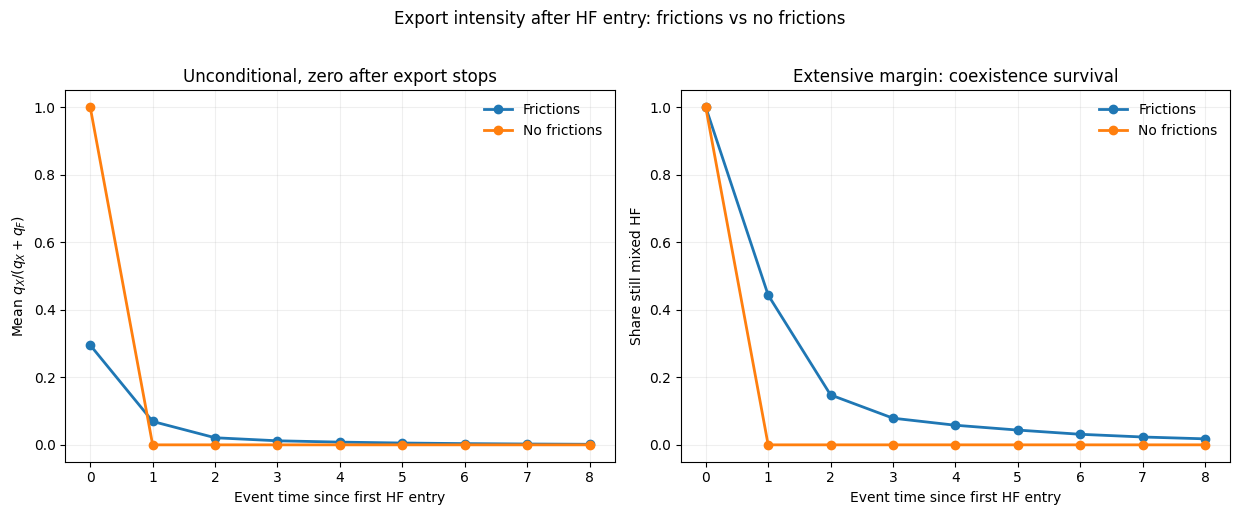

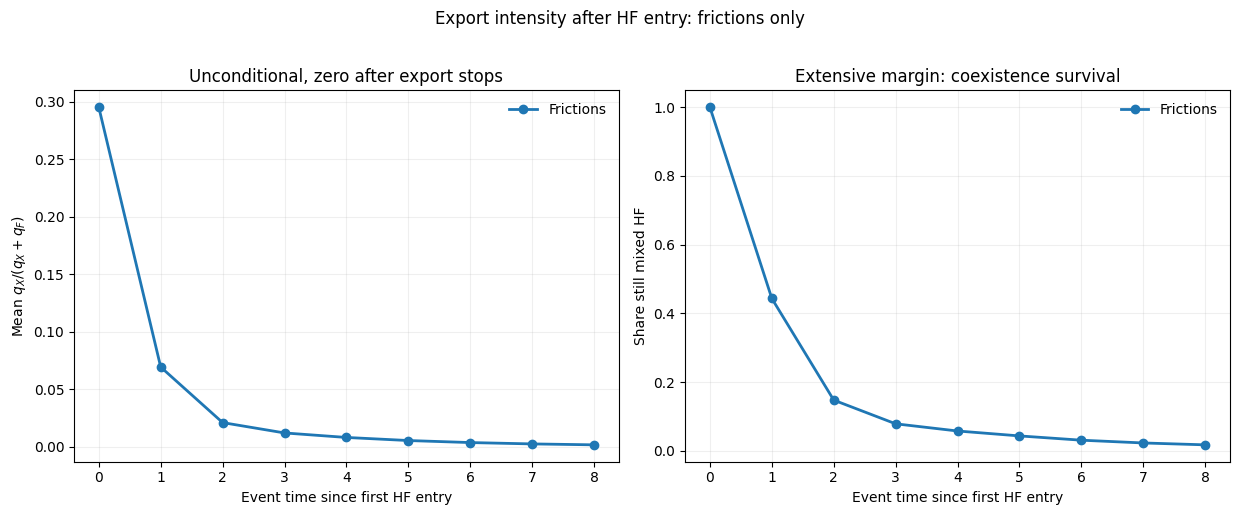

In [91]:
# %%
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def build_export_share_event_df_for_coexistence_entrants(
    long_df: pd.DataFrame,
    summary_df: pd.DataFrame,
    window_post: int = 8,
) -> pd.DataFrame:
    """
    Build event-time panel for firms that enter HF with exports.
    """
    entrants = summary_df.loc[
        (summary_df["ever_hf"] == 1) &
        (summary_df["coexist_at_hf_entry"] == 1),
        ["state_id", "firm_id", "first_hf_period"]
    ].copy()

    df = long_df.merge(
        entrants,
        on=["state_id", "firm_id"],
        how="inner",
        validate="many_to_one",
    )

    rows = []

    for (state_id, firm_id), sub in df.groupby(["state_id", "firm_id"]):
        sub = sub.sort_values("t").reset_index(drop=True)
        entry_t = int(sub["first_hf_period"].iloc[0])

        for tau in range(0, window_post + 1):
            t = entry_t + tau
            hit = sub.loc[sub["t"] == t]

            if len(hit) == 0:
                continue

            r = hit.iloc[0]

            if (r["is_hf_t"] == 1) and (r["is_exporting_in_hf_t"] == 1):
                export_share_unconditional = float(r["export_share_foreign_t"])
                is_still_mixed_hf = 1
            else:
                export_share_unconditional = 0.0
                is_still_mixed_hf = 0

            rows.append({
                "state_id": state_id,
                "firm_id": firm_id,
                "event_time": tau,
                "export_share_unconditional": export_share_unconditional,
                "is_still_mixed_hf": is_still_mixed_hf,
            })

    return pd.DataFrame(rows)


def plot_export_share_event_study_selected_panels(
    long_df_fric: pd.DataFrame,
    summary_df_fric: pd.DataFrame,
    long_df_nofric: pd.DataFrame | None = None,
    summary_df_nofric: pd.DataFrame | None = None,
    window_post: int = 8,
    label_fric: str = "Frictions",
    label_nofric: str = "No frictions",
    show: bool = True,
):
    """
    Plot:
      1. Unconditional qX/(qX+qF), with zeros after export stops
      2. Share still mixed HF

    If no-frictions inputs are provided, plot both cases.
    Otherwise plot frictions only.

    Returns
    -------
    fig, axes, event_df, agg
    """
    df_fric = build_export_share_event_df_for_coexistence_entrants(
        long_df=long_df_fric,
        summary_df=summary_df_fric,
        window_post=window_post,
    )
    df_fric["case"] = label_fric

    frames = [df_fric]

    include_nofric = (long_df_nofric is not None) and (summary_df_nofric is not None)

    if include_nofric:
        df_nofric = build_export_share_event_df_for_coexistence_entrants(
            long_df=long_df_nofric,
            summary_df=summary_df_nofric,
            window_post=window_post,
        )
        df_nofric["case"] = label_nofric
        frames.append(df_nofric)

    event_df = pd.concat(frames, ignore_index=True)

    agg = (
        event_df.groupby(["case", "event_time"], as_index=False)
        .agg(
            mean_export_share_unconditional=("export_share_unconditional", "mean"),
            median_export_share_unconditional=("export_share_unconditional", "median"),
            share_still_mixed_hf=("is_still_mixed_hf", "mean"),
            n_obs=("firm_id", "count"),
        )
    )

    fig, axes = plt.subplots(1, 2, figsize=(12.5, 5.0), sharex=True)

    for label, sub in agg.groupby("case"):
        sub = sub.sort_values("event_time")

        axes[0].plot(
            sub["event_time"],
            sub["mean_export_share_unconditional"],
            marker="o",
            linewidth=2,
            label=label,
        )
        axes[1].plot(
            sub["event_time"],
            sub["share_still_mixed_hf"],
            marker="o",
            linewidth=2,
            label=label,
        )

    axes[0].set_xlabel("Event time since first HF entry")
    axes[0].set_ylabel(r"Mean $q_X/(q_X+q_F)$")
    axes[0].set_title("Unconditional, zero after export stops")
    axes[0].grid(alpha=0.2)
    axes[0].legend(frameon=False)

    axes[1].set_xlabel("Event time since first HF entry")
    axes[1].set_ylabel("Share still mixed HF")
    axes[1].set_title("Extensive margin: coexistence survival")
    axes[1].grid(alpha=0.2)
    axes[1].legend(frameon=False)

    if include_nofric:
        fig.suptitle("Export intensity after HF entry: frictions vs no frictions", y=1.02)
    else:
        fig.suptitle("Export intensity after HF entry: frictions only", y=1.02)

    plt.tight_layout()

    if show:
        plt.show()

    return fig, axes, event_df, agg

# Frictions and no-frictions together
fig0, axes, export_share_event_df, export_share_event_agg = plot_export_share_event_study_selected_panels(
    long_df_fric=long_df,
    summary_df_fric=summary_df,
    long_df_nofric=long_df_NF,
    summary_df_nofric=summary_df_NF,
    window_post=8,
    label_fric="Frictions",
    label_nofric="No frictions",
)

# Run only fritions 
fig, axes, export_share_event_df, export_share_event_agg = plot_export_share_event_study_selected_panels(
    long_df_fric=long_df,
    summary_df_fric=summary_df,
    window_post=8,
    label_fric="Frictions",
)

fig.savefig("output/export_share_event_study.png", dpi=300, bbox_inches="tight")
plt.show()

These figures are coneditional on firms entering with positive exports 
#### First figure
In the no frictions case, there is no reason to build up $K_F$ before entry because can directly adjust capital stock without convex costs. As a result firms immediatly go from 1 to 0 in the next period. As shown below this coexistence group for the no frictions case is really small. 

In the frictions case, firms have already build up a small stock of $K_F$ and can therefore immediately produce abroad when entering. Exporting remains relevant for 3/4 periods but drops op over time. 

#### Second figure 
restrict to frictions only for exposition

In [76]:
# %%
def inspect_coexistence_entrants_at_entry(long_df: pd.DataFrame, summary_df: pd.DataFrame, label: str):
    entrants = summary_df.loc[
        (summary_df["ever_hf"] == 1) &
        (summary_df["coexist_at_hf_entry"] == 1),
        ["state_id", "firm_id", "first_hf_period"]
    ].copy()

    df = long_df.merge(
        entrants,
        on=["state_id", "firm_id"],
        how="inner",
        validate="many_to_one",
    )

    df = df.loc[df["t"] == df["first_hf_period"]].copy()

    out = {
        "case": label,
        "n_entrants_with_exports": len(df),
        "mean_export_share_at_entry": df["export_share_foreign_t"].mean(),
        "median_export_share_at_entry": df["export_share_foreign_t"].median(),
        "mean_KF_entry": df["KF_t"].mean(),
        "median_KF_entry": df["KF_t"].median(),
        "mean_psi_over_GammaX_entry": df["psi_over_GammaX_t"].mean(),
        "median_psi_over_GammaX_entry": df["psi_over_GammaX_t"].median(),
    }
    return pd.DataFrame([out])

inspect_fric = inspect_coexistence_entrants_at_entry(long_df, summary_df, "Frictions")
inspect_nf = inspect_coexistence_entrants_at_entry(long_df_NF, summary_df_NF, "No frictions")

pd.concat([inspect_fric, inspect_nf], ignore_index=True)

,case,n_entrants_with_exports,mean_export_share_at_entry,median_export_share_at_entry,mean_KF_entry,median_KF_entry,mean_psi_over_GammaX_entry,median_psi_over_GammaX_entry
0,Frictions,40798,0.295329,0.309475,0.535062,0.526316,0.619131,0.586711
1,No frictions,2435,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000


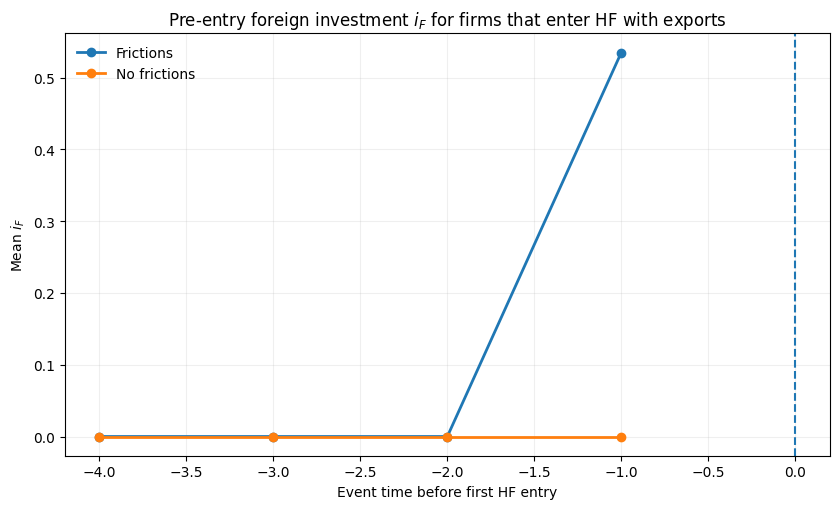

           case  event_time   mean_iF  median_iF  n_obs
0     Frictions          -4  0.000000   0.000000   2109
1     Frictions          -3  0.000000   0.000000   3070
2     Frictions          -2  0.000000   0.000000   4498
3     Frictions          -1  0.535062   0.526316  40798
4  No frictions          -4  0.000000   0.000000    524
5  No frictions          -3  0.000000   0.000000   1029
6  No frictions          -2  0.000000   0.000000   1412
7  No frictions          -1  0.000000   0.000000   2435


In [78]:
# %%
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def build_pre_entry_iF_df_for_coexistence_entrants(
    long_df: pd.DataFrame,
    summary_df: pd.DataFrame,
    window_pre: int = 4,
) -> pd.DataFrame:
    """
    Build an event-time panel for firms that enter HF with exports
    (coexist_at_hf_entry == 1), keeping only pre-entry periods.

    Event time:
      tau = -window_pre, ..., -1
      where tau = 0 would be first HF entry

    Output columns:
      - event_time
      - iF_t
    """
    entrants = summary_df.loc[
        (summary_df["ever_hf"] == 1) &
        (summary_df["coexist_at_hf_entry"] == 1),
        ["state_id", "firm_id", "first_hf_period"]
    ].copy()

    df = long_df.merge(
        entrants,
        on=["state_id", "firm_id"],
        how="inner",
        validate="many_to_one",
    )

    rows = []

    for (state_id, firm_id), sub in df.groupby(["state_id", "firm_id"]):
        sub = sub.sort_values("t").reset_index(drop=True)
        entry_t = int(sub["first_hf_period"].iloc[0])

        for tau in range(-window_pre, 0):
            t = entry_t + tau
            hit = sub.loc[sub["t"] == t]

            if len(hit) == 0:
                continue

            r = hit.iloc[0]

            rows.append({
                "state_id": state_id,
                "firm_id": firm_id,
                "event_time": int(tau),
                "iF_t": float(r["iF_t"]),
            })

    return pd.DataFrame(rows)


def plot_pre_entry_iF_comparison_for_coexistence_group(
    long_df_fric: pd.DataFrame,
    summary_df_fric: pd.DataFrame,
    long_df_nofric: pd.DataFrame,
    summary_df_nofric: pd.DataFrame,
    window_pre: int = 4,
    label_fric: str = "Frictions",
    label_nofric: str = "No frictions",
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Compare pre-entry foreign investment i_F for the coexistence group
    (firms that enter HF with exports) across frictions vs no frictions.
    """
    df_fric = build_pre_entry_iF_df_for_coexistence_entrants(
        long_df=long_df_fric,
        summary_df=summary_df_fric,
        window_pre=window_pre,
    )
    df_fric["case"] = label_fric

    df_nofric = build_pre_entry_iF_df_for_coexistence_entrants(
        long_df=long_df_nofric,
        summary_df=summary_df_nofric,
        window_pre=window_pre,
    )
    df_nofric["case"] = label_nofric

    event_df = pd.concat([df_fric, df_nofric], ignore_index=True)

    agg = (
        event_df.groupby(["case", "event_time"], as_index=False)
                .agg(
                    mean_iF=("iF_t", "mean"),
                    median_iF=("iF_t", "median"),
                    n_obs=("firm_id", "count"),
                )
    )

    fig, ax = plt.subplots(figsize=(8.5, 5.2))

    for label, sub in agg.groupby("case"):
        sub = sub.sort_values("event_time")
        ax.plot(
            sub["event_time"],
            sub["mean_iF"],
            marker="o",
            linewidth=2,
            label=label,
        )

    ax.axvline(0, linestyle="--")
    ax.set_xlabel("Event time before first HF entry")
    ax.set_ylabel(r"Mean $i_F$")
    ax.set_title(r"Pre-entry foreign investment $i_F$ for firms that enter HF with exports")
    ax.grid(alpha=0.2)
    ax.legend(frameon=False)

    plt.tight_layout()
    plt.show()

    return event_df, agg


# Run
pre_entry_iF_df, pre_entry_iF_agg = plot_pre_entry_iF_comparison_for_coexistence_group(
    long_df_fric=long_df,
    summary_df_fric=summary_df,
    long_df_nofric=long_df_NF,
    summary_df_nofric=summary_df_NF,
    window_pre=4,
    label_fric="Frictions",
    label_nofric="No frictions",
)

print(pre_entry_iF_agg)

### Event study of the investment paths

In [99]:
# %%
def build_hf_entry_event_study_df(
    long_df: pd.DataFrame,
    summary_df: pd.DataFrame,
    window_pre: int = 2,
    window_post: int = 2,
    min_group_size: int = 10,
) -> pd.DataFrame:
    """
    Align firms by first HF entry and split by:
      - coexist_at_hf_entry = 1  -> enters HF and still exports
      - coexist_at_hf_entry = 0  -> enters HF and immediately becomes pure affiliate
    """
    entrants = summary_df.loc[summary_df["ever_hf"] == 1, [
        "state_id", "firm_id", "first_hf_period", "coexist_at_hf_entry"
    ]].copy()

    df = long_df.merge(
        entrants,
        on=["state_id", "firm_id"],
        how="inner",
    )

    rows = []
    event_times = np.arange(-window_pre, window_post + 1)

    for (state_id, firm_id), sub in df.groupby(["state_id", "firm_id"]):
        sub = sub.sort_values("t").reset_index(drop=True)
        entry_t = int(sub["first_hf_period"].iloc[0])
        coexist_group = int(sub["coexist_at_hf_entry"].iloc[0])

        group_label = (
            "HF entry with exports"
            if coexist_group == 1
            else "HF entry without exports"
        )

        for tau in event_times:
            t = entry_t + tau
            hit = sub.loc[sub["t"] == t]

            if len(hit) == 0:
                continue

            r = hit.iloc[0]

            rows.append({
                "state_id": state_id,
                "firm_id": firm_id,
                "group": group_label,
                "event_time": int(tau),

                "KH_t": float(r["KH_t"]),
                "KF_t": float(r["KF_t"]),
                "iH_t": float(r["iH_t"]),
                "iF_t": float(r["iF_t"]),

                "is_hf_t": int(r["is_hf_t"]),
                "is_exporting_in_hf_t": int(r["is_exporting_in_hf_t"]),
                "export_share_foreign_t": float(r["export_share_foreign_t"]),
            })

    out = pd.DataFrame(rows)

    group_sizes = out.groupby("group")["firm_id"].nunique()
    keep_groups = group_sizes[group_sizes >= min_group_size].index.tolist()
    out = out[out["group"].isin(keep_groups)].copy()

    return out


# %%
def plot_hf_entry_event_study_by_type(
    long_df: pd.DataFrame,
    summary_df: pd.DataFrame,
    window_pre: int = 2,
    window_post: int = 2,
    min_group_size: int = 10,
    show: bool = True,
):
    evt = build_hf_entry_event_study_df(
        long_df=long_df,
        summary_df=summary_df,
        window_pre=window_pre,
        window_post=window_post,
        min_group_size=min_group_size,
    )

    if len(evt) == 0:
        raise ValueError("No event-study observations after applying min_group_size.")

    agg = (
        evt.groupby(["group", "event_time"], as_index=False)
           .agg(
               KH_t=("KH_t", "mean"),
               KF_t=("KF_t", "mean"),
               iH_t=("iH_t", "mean"),
               iF_t=("iF_t", "mean"),
               export_share_foreign_t=("export_share_foreign_t", "mean"),
               n_obs=("firm_id", "count"),
           )
    )

    fig, axes = plt.subplots(2, 2, figsize=(13.5, 8.5), sharex=True)

    for group, sub in agg.groupby("group"):
        sub = sub.sort_values("event_time")

        axes[0, 0].plot(sub["event_time"], sub["iH_t"], marker="o", label=group)
        axes[0, 1].plot(sub["event_time"], sub["iF_t"], marker="o", label=group)
        axes[1, 0].plot(sub["event_time"], sub["KH_t"], marker="o", label=group)
        axes[1, 1].plot(sub["event_time"], sub["KF_t"], marker="o", label=group)

    for ax in axes.ravel():
        ax.axvline(0, linestyle="--")
        ax.grid(alpha=0.2)

    axes[0, 0].set_title(r"Home investment $i_H$")
    axes[0, 1].set_title(r"Foreign investment $i_F$")
    axes[1, 0].set_title(r"Home capital $K_H$")
    axes[1, 1].set_title(r"Foreign capital $K_F$")

    axes[1, 0].set_xlabel("Event time since first HF entry")
    axes[1, 1].set_xlabel("Event time since first HF entry")
    axes[0, 0].set_ylabel("Mean")
    axes[1, 0].set_ylabel("Mean")

    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="lower center", bbox_to_anchor=(0.5, -0.02), ncol=2, frameon=False)
    fig.suptitle("HF-entry event study by type of entrant", y=1.02)
    plt.tight_layout(rect=[0, 0.04, 1, 0.97])

    if show:
        plt.show()

    return agg, fig, axes

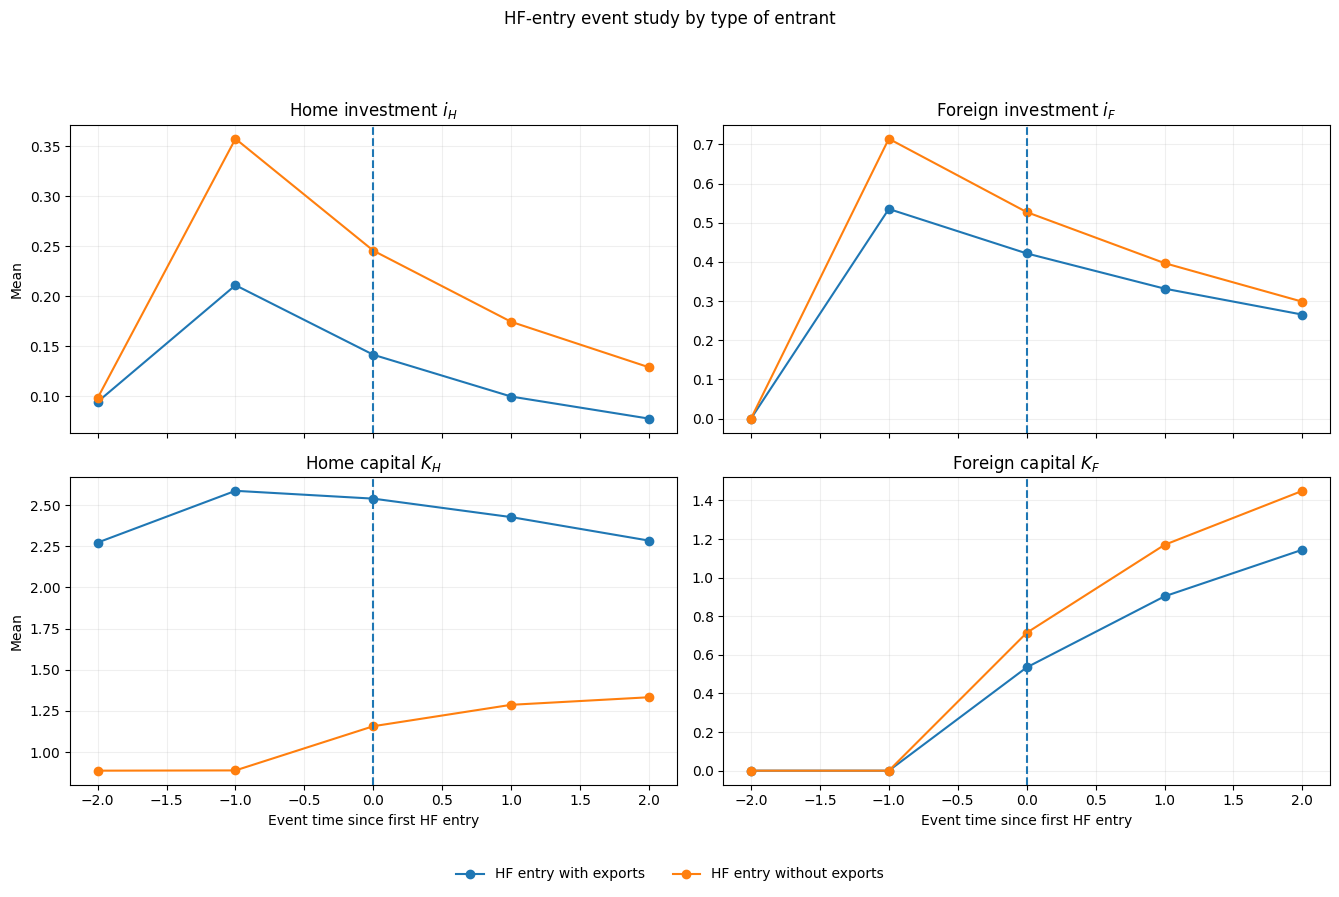

In [100]:
# %%
import os
os.makedirs("output", exist_ok=True)

agg, fig, axes = plot_hf_entry_event_study_by_type(
    long_df=long_df,
    summary_df=summary_df,
    window_pre=2,
    window_post=2,
    min_group_size=10,
    show=False,
)

fig.savefig("output/hf_entry_event_study_by_type.png", dpi=300, bbox_inches="tight")
plt.show()

Exporting in the model happens when $\varphi < \Gamma_X$. $\varphi$ depends on the relative capacity ratio $K_F/K_H$. It can be seen that the firms with lower $K_H$ are the firms which do not export in the beginning. since $K_F$ is the same intially $\varphi$ is lower for the orange curves. 

- mixed-HF entrants start with a large home-capital base and allow it to run down gradually,
- pure-affiliate entrants start with a low home-capital base and build it up somewhat, but remain much less home-capital intensive.

notes: 
- Firms peak their investment right before entry. 
- The firms which do NOT export when entering HF are the firms with a low home capital stock $K_H$. Their foreign capital path is relatively similar. You see that firms which export after entry generally decrease their capital stock and have lower inveswtments while firms which NOT export let their capital stock decrease. 


## Coexistence and initial productivity
How does coexistence of export/affiliate depend on inital productivity and entrance probability? 

The RESULTS below show
1. Firms with lower inital productivity have a higher mass of firms which enter HF with exports whereas HF without exports has more density for higher inital productivity firms


In [ ]:
# %%
def compare_entry_states_by_hf_type(long_df: pd.DataFrame, summary_df: pd.DataFrame) -> pd.DataFrame:
    """
    Compare entry states for:
      - HF entry with exports
      - HF entry without exports
    """
    entrants = summary_df.loc[summary_df["ever_hf"] == 1, [
        "state_id",
        "firm_id",
        "first_hf_period",
        "coexist_at_hf_entry",
    ]].copy()

    entry_rows = long_df.merge(
        entrants,
        on=["state_id", "firm_id"],
        how="inner",
        validate="many_to_one",
    )

    # Keep only the period of first HF entry
    entry_rows = entry_rows.loc[
        entry_rows["t"] == entry_rows["first_hf_period"]
    ].copy()

    entry_rows["entry_type"] = np.where(
        entry_rows["coexist_at_hf_entry"] == 1,
        "HF entry with exports",
        "HF entry without exports",
    )

    entry_rows["KF_over_KH_entry"] = entry_rows["KF_t"] / np.maximum(entry_rows["KH_t"], 1e-10)

    out = (
        entry_rows
        .groupby("entry_type", as_index=False)
        .agg(
            n_firms=("firm_id", "count"),
            mean_s0=("s0", "mean"),
            mean_s_entry=("s_t", "mean"),
            mean_KH_entry=("KH_t", "mean"),
            mean_KF_entry=("KF_t", "mean"),
            mean_KF_over_KH_entry=("KF_over_KH_entry", "mean"),
            mean_psi_over_GammaX_entry=("psi_over_GammaX_t", "mean"),
        )
    )

    return out

entry_type_compare = compare_entry_states_by_hf_type(long_df, summary_df)
print(entry_type_compare)

                 entry_type  n_firms   mean_s0  mean_s_entry  mean_KH_entry  \
0     HF entry with exports    40798  1.980303      1.892497       2.539220   
1  HF entry without exports    23244  2.204891      2.048659       1.156957   

   mean_KF_entry  mean_KF_over_KH_entry  mean_psi_over_GammaX_entry  
0       0.535062               0.222160                    0.619131  
1       0.714240               0.742937                    2.070472  


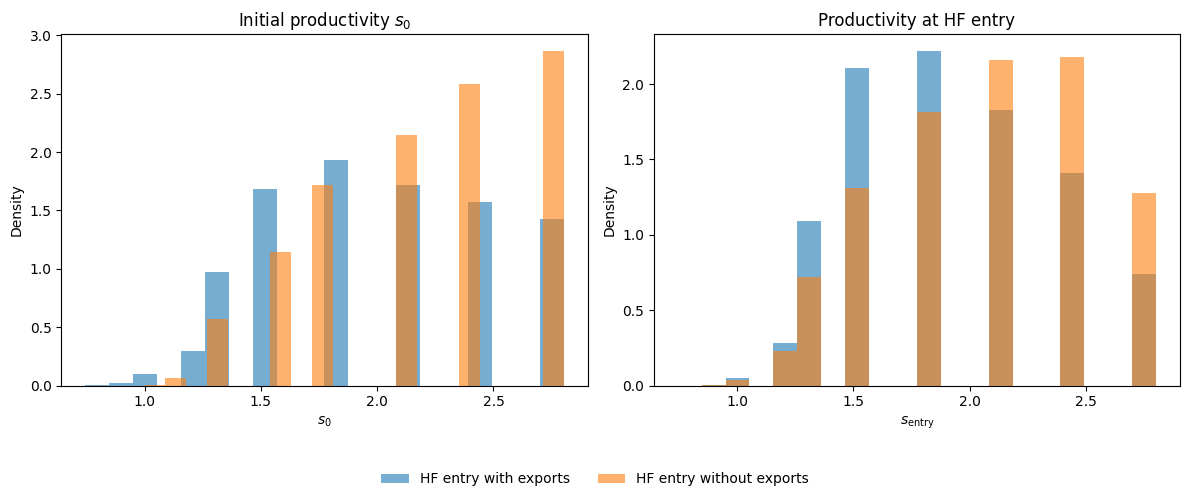

In [64]:
# %%
def plot_entry_productivity_by_hf_type(long_df: pd.DataFrame, summary_df: pd.DataFrame, bins: int = 20) -> None:
    entrants = summary_df.loc[summary_df["ever_hf"] == 1, [
        "state_id",
        "firm_id",
        "first_hf_period",
        "coexist_at_hf_entry",
    ]].copy()

    entry_rows = long_df.merge(
        entrants,
        on=["state_id", "firm_id"],
        how="inner",
        validate="many_to_one",
    )

    entry_rows = entry_rows.loc[
        entry_rows["t"] == entry_rows["first_hf_period"]
    ].copy()

    df_mixed = entry_rows.loc[entry_rows["coexist_at_hf_entry"] == 1]
    df_pure = entry_rows.loc[entry_rows["coexist_at_hf_entry"] == 0]

    fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))

    axes[0].hist(df_mixed["s0"], bins=bins, density=True, alpha=0.6, label="HF entry with exports")
    axes[0].hist(df_pure["s0"], bins=bins, density=True, alpha=0.6, label="HF entry without exports")
    axes[0].set_title(r"Initial productivity $s_0$")
    axes[0].set_xlabel(r"$s_0$")
    axes[0].set_ylabel("Density")

    axes[1].hist(df_mixed["s_t"], bins=bins, density=True, alpha=0.6, label="HF entry with exports")
    axes[1].hist(df_pure["s_t"], bins=bins, density=True, alpha=0.6, label="HF entry without exports")
    axes[1].set_title(r"Productivity at HF entry")
    axes[1].set_xlabel(r"$s_{\mathrm{entry}}$")
    axes[1].set_ylabel("Density")

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="lower center", bbox_to_anchor=(0.5, -0.05), ncol=2, frameon=False)
    plt.tight_layout(rect=[0, 0.06, 1, 1])
    plt.show()


plot_entry_productivity_by_hf_type(long_df, summary_df, bins=20)

In [67]:
# %%
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def build_entry_state_space_df(long_df: pd.DataFrame, summary_df: pd.DataFrame) -> pd.DataFrame:
    """
    Build a firm-level DataFrame at the period of first HF entry.

    Required columns in long_df:
      - state_id, firm_id, t, s0, s_t, KH_t, KF_t, psi_over_GammaX_t
    Required columns in summary_df:
      - state_id, firm_id, ever_hf, first_hf_period, coexist_at_hf_entry
    """
    required_long = [
        "state_id", "firm_id", "t", "s0", "s_t", "KH_t", "KF_t", "psi_over_GammaX_t"
    ]
    required_summary = [
        "state_id", "firm_id", "ever_hf", "first_hf_period", "coexist_at_hf_entry"
    ]

    missing_long = [c for c in required_long if c not in long_df.columns]
    missing_summary = [c for c in required_summary if c not in summary_df.columns]

    if missing_long:
        raise KeyError(f"long_df is missing columns: {missing_long}")
    if missing_summary:
        raise KeyError(f"summary_df is missing columns: {missing_summary}")

    entrants = summary_df.loc[summary_df["ever_hf"] == 1, required_summary].copy()

    entry_df = long_df[required_long].merge(
        entrants,
        on=["state_id", "firm_id"],
        how="inner",
        validate="many_to_one",
    )

    # Keep only the period of first HF entry
    entry_df = entry_df.loc[
        entry_df["t"] == entry_df["first_hf_period"]
    ].copy()

    entry_df = entry_df.rename(columns={
        "s_t": "s_entry",
        "KH_t": "KH_entry",
        "KF_t": "KF_entry",
        "psi_over_GammaX_t": "psi_over_GammaX_entry",
    })

    entry_df["KF_over_KH_entry"] = (
        entry_df["KF_entry"] / np.maximum(entry_df["KH_entry"], 1e-10)
    )

    entry_df["entry_type"] = np.where(
        entry_df["coexist_at_hf_entry"] == 1,
        "HF entry with exports",
        "HF entry without exports",
    )

    return entry_df.reset_index(drop=True)


entry_state_df = build_entry_state_space_df(long_df, summary_df)
print(entry_state_df.head())
print(entry_state_df["entry_type"].value_counts())

   state_id  firm_id  t        s0   s_entry  KH_entry  KF_entry  \
0         0        1  5  0.745048  1.801489       2.4  0.421053   
1         0       11  7  0.745048  1.801489       2.0  0.315789   
2         1       22  6  0.745048  1.554976       2.2  0.421053   
3         3       54  6  0.745048  2.087083       2.4  0.315789   
4         5      150  8  0.745048  1.801489       2.4  0.421053   

   psi_over_GammaX_entry  ever_hf  first_hf_period  coexist_at_hf_entry  \
0               0.488925        1              5.0                  1.0   
1               0.440033        1              7.0                  1.0   
2               0.533373        1              6.0                  1.0   
3               0.366694        1              6.0                  1.0   
4               0.488925        1              8.0                  1.0   

   KF_over_KH_entry             entry_type  
0          0.175439  HF entry with exports  
1          0.157895  HF entry with exports  
2          

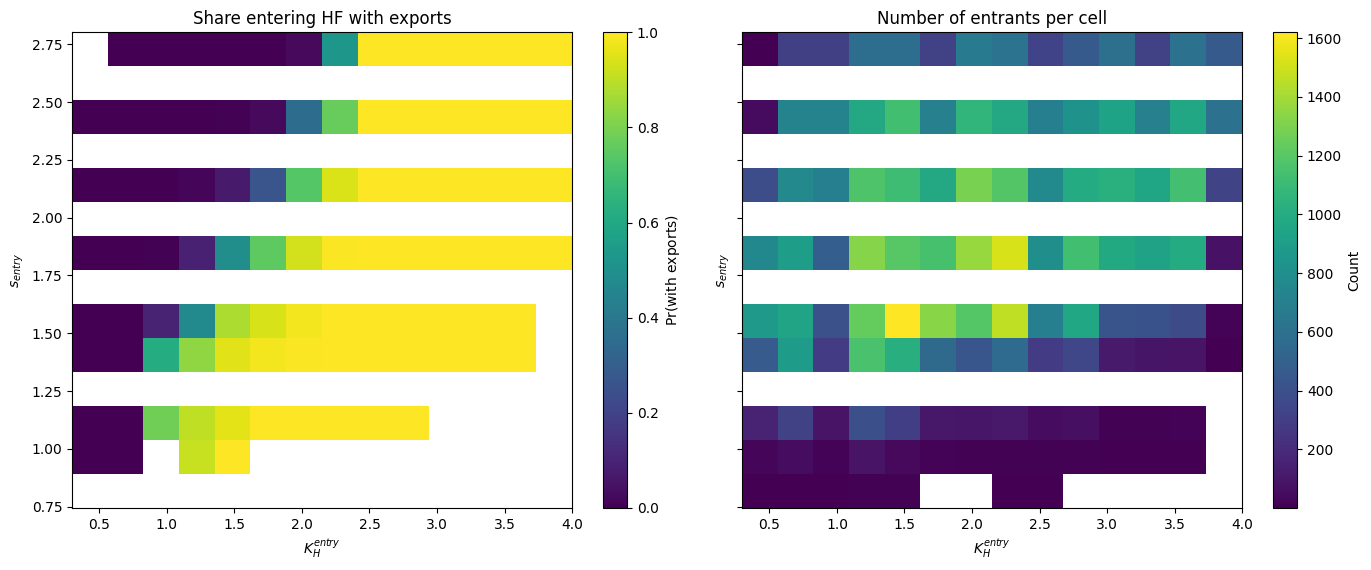

In [68]:
# %%
def plot_entry_state_space_heatmap(
    entry_state_df: pd.DataFrame,
    n_bins_kh: int = 14,
    n_bins_s: int = 14,
    min_count_per_bin: int = 20,
) -> pd.DataFrame:
    """
    Heatmap over (KH_entry, s_entry) cells showing the share of entrants
    that enter HF with exports.

    Cell value:
        mean(coexist_at_hf_entry)

    min_count_per_bin:
        mask cells with too few observations
    """
    df = entry_state_df.copy()

    kh_min, kh_max = df["KH_entry"].min(), df["KH_entry"].max()
    s_min, s_max = df["s_entry"].min(), df["s_entry"].max()

    kh_edges = np.linspace(kh_min, kh_max, n_bins_kh + 1)
    s_edges = np.linspace(s_min, s_max, n_bins_s + 1)

    df["kh_bin"] = pd.cut(df["KH_entry"], bins=kh_edges, include_lowest=True, labels=False)
    df["s_bin"] = pd.cut(df["s_entry"], bins=s_edges, include_lowest=True, labels=False)

    grouped = (
        df.groupby(["s_bin", "kh_bin"], as_index=False)
          .agg(
              share_with_exports=("coexist_at_hf_entry", "mean"),
              n_obs=("firm_id", "count"),
          )
    )

    # Complete rectangular grid
    full_index = pd.MultiIndex.from_product(
        [range(n_bins_s), range(n_bins_kh)],
        names=["s_bin", "kh_bin"]
    )
    grouped = (
        grouped.set_index(["s_bin", "kh_bin"])
               .reindex(full_index)
               .reset_index()
    )

    grouped.loc[grouped["n_obs"] < min_count_per_bin, "share_with_exports"] = np.nan

    Z = grouped.pivot(index="s_bin", columns="kh_bin", values="share_with_exports").to_numpy(dtype=float)
    N = grouped.pivot(index="s_bin", columns="kh_bin", values="n_obs").to_numpy(dtype=float)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5.8), sharey=True)

    # Left: share of entrants that continue exporting
    im1 = axes[0].imshow(
        np.ma.masked_invalid(Z),
        origin="lower",
        aspect="auto",
        extent=[kh_edges[0], kh_edges[-1], s_edges[0], s_edges[-1]],
        vmin=0.0,
        vmax=1.0,
    )
    axes[0].set_xlabel(r"$K_H^{entry}$")
    axes[0].set_ylabel(r"$s_{entry}$")
    axes[0].set_title(r"Share entering HF with exports")
    fig.colorbar(im1, ax=axes[0], label=r"$\Pr(\mathrm{with\ exports})$")

    # Right: counts per cell
    im2 = axes[1].imshow(
        np.ma.masked_invalid(N),
        origin="lower",
        aspect="auto",
        extent=[kh_edges[0], kh_edges[-1], s_edges[0], s_edges[-1]],
    )
    axes[1].set_xlabel(r"$K_H^{entry}$")
    axes[1].set_ylabel(r"$s_{entry}$")
    axes[1].set_title("Number of entrants per cell")
    fig.colorbar(im2, ax=axes[1], label="Count")

    plt.tight_layout()
    plt.show()

    return grouped


entry_state_bins_df = plot_entry_state_space_heatmap(
    entry_state_df,
    n_bins_kh=14,
    n_bins_s=14,
    min_count_per_bin=20,
)